## Como Ler Este Volume

1. Visão geral do projeto.
2. Contexto metodológico e bases utilizadas.
3. Construção da base integrada e organização dos arquivos principais.
4. Resultados, comparações e visualizações.
5. Dicionário de dados e validação dos arquivos finais.
6. Apêndice técnico com benchmark de formatos de armazenamento.
7. Apêndice documental com síntese das validações do projeto.


## 2. Contexto do Estudo

Este projeto foi organizado como um estudo **quantitativo, aplicado, descritivo e exploratório**. O foco está em integrar bases públicas, organizar os dados com cuidado e interpretar padrões observados nos municípios brasileiros.

A base do trabalho articula população municipal, PAM, PPM, Censo Agropecuário e indicadores educacionais rurais. A integração é feita com `codigo_municipio` de 7 dígitos, e o recorte `Rural` permanece explícito no bloco educacional.

Neste volume, todo o conteúdo principal foi reunido em um único notebook para favorecer uma leitura contínua e uma execução mais direta.


## 3. Base Integrada e Preparação dos Dados

A seguir está o núcleo operacional do projeto: a leitura dos artefatos finais, o resumo das fontes, a base longa consolidada, o snapshot analítico e as verificações estruturais dos arquivos principais.


In [1]:
from __future__ import annotations

import os
import warnings
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

REGIME_VALUES = [
    "intensificacao_com_esvaziamento_e_fragilidade",
    "intensificacao_com_fragilidade_educacional",
    "intensificacao_com_adaptacao_relativa",
    "baixa_pressao_territorial",
    "dados_insuficientes",
]
SUBDOMINIOS_CENTRAIS = {
    "populacao_municipal",
    "pam_area_colhida",
    "ppm_rebanhos",
    "censo_agro_estrutura",
    "censo_agro_mecanizacao",
    "matriculas_ensino_medio",
    "rendimento_escolar",
}
SNAPSHOT_COLUNAS_CENTRAIS = {
    "taxa_abandono_rural_2024",
    "matriculas_ensino_medio_rural_2024",
    "efetivo_bovino_2010",
    "efetivo_bovino_2024",
    "regime_territorial",
}
METRICAS_DESCRITIVAS = [
    "populacao_total_2024",
    "area_total_culturas_selecionadas_hectares_2024",
    "efetivo_bovino_2024",
    "matriculas_ensino_medio_rural_2024",
    "taxa_abandono_rural_2024",
    "escore_intensificacao_agropecuaria_2024",
]


@dataclass
class PipelineArtifacts:
    configuracao: pd.DataFrame
    checkpoints_etl: pd.DataFrame
    base_longa: pd.DataFrame
    snapshot_analitico: pd.DataFrame
    validacoes: pd.DataFrame
    revisao_amostral: pd.DataFrame
    resumo_exportacao: pd.DataFrame
    tabela_descritiva: pd.DataFrame
    comparacao_quartis: pd.DataFrame
    comparacao_regiao: pd.DataFrame
    comparacao_porte: pd.DataFrame
    resumo_regimes: pd.DataFrame
    matriz_correlacao: pd.DataFrame
    municipios_destaque_regime: pd.DataFrame
    conclusao_markdown: str
    long_output_path: Path
    analytic_output_path: Path



def descobrir_raiz_projeto() -> Path:
    candidatos = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidato in candidatos:
        if (candidato / "dados").exists() and (candidato / "notebooks").exists():
            return candidato
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto.")


PROJECT_ROOT = descobrir_raiz_projeto()
LONG_OUTPUT = PROJECT_ROOT / "dados" / "saidas_finais" / "master_municipios_longo.csv"
ANALYTIC_OUTPUT = PROJECT_ROOT / "dados" / "saidas_finais" / "master_municipios_analitico_snapshot.csv"
VOLUME_PATH = PROJECT_ROOT / "notebooks" / "PAD_projeto.ipynb"



def carregar_csv_obrigatorio(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {path}")
    return pd.read_csv(path, low_memory=False)



def normalizar_codigo_ibge(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .str.replace(".0", "", regex=False)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(7)
    )



def plotar_barras(series: pd.Series, title: str, ylabel: str) -> None:
    plot_series = pd.Series(series).fillna(0)
    plt.figure(figsize=(10, 4))
    plot_series.plot(kind="bar", color="#4daf4a")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()



def formatar_agregacao(dataframe: pd.DataFrame, group_col: str) -> pd.DataFrame:
    agregado = (
        dataframe.dropna(subset=[group_col])
        .groupby(group_col)
        .agg(
            municipios=("codigo_municipio", "nunique"),
            populacao_media_2024=("populacao_total_2024", "mean"),
            area_culturas_media_2024=("area_total_culturas_selecionadas_hectares_2024", "mean"),
            efetivo_bovino_medio_2024=("efetivo_bovino_2024", "mean"),
            abandono_medio_2024=("taxa_abandono_rural_2024", "mean"),
            escore_agro_medio_2024=("escore_intensificacao_agropecuaria_2024", "mean"),
        )
        .reset_index()
    )
    for col in agregado.columns:
        if col != group_col and pd.api.types.is_numeric_dtype(agregado[col]):
            agregado[col] = agregado[col].round(2)
    return agregado



def montar_validacoes(base_longa: pd.DataFrame, snapshot: pd.DataFrame) -> pd.DataFrame:
    long_codes = normalizar_codigo_ibge(base_longa["codigo_municipio"])
    snap_codes = normalizar_codigo_ibge(snapshot["codigo_municipio"])
    long_subdominios = set(base_longa["subdominio"].dropna().astype(str))
    snapshot_regimes = set(snapshot["regime_territorial"].dropna().astype(str))
    rows = [
        {
            "validacao": "base_longa_colunas_esperadas",
            "status": bool(base_longa.shape[1] == 21),
            "detalhe": f"{base_longa.shape[1]} colunas observadas",
        },
        {
            "validacao": "snapshot_colunas_esperadas",
            "status": bool(snapshot.shape[1] == 39),
            "detalhe": f"{snapshot.shape[1]} colunas observadas",
        },
        {
            "validacao": "codigos_base_longa_com_7_digitos",
            "status": bool(long_codes.str.fullmatch(r"\d{7}").fillna(False).all()),
            "detalhe": f"{long_codes.nunique()} codigos municipais distintos",
        },
        {
            "validacao": "codigos_snapshot_com_7_digitos",
            "status": bool(snap_codes.str.fullmatch(r"\d{7}").fillna(False).all()),
            "detalhe": f"{snap_codes.nunique()} codigos municipais distintos",
        },
        {
            "validacao": "subdominios_centrais_presentes",
            "status": SUBDOMINIOS_CENTRAIS.issubset(long_subdominios),
            "detalhe": ", ".join(sorted(SUBDOMINIOS_CENTRAIS - long_subdominios)) or "todos presentes",
        },
        {
            "validacao": "colunas_centrais_snapshot_presentes",
            "status": SNAPSHOT_COLUNAS_CENTRAIS.issubset(snapshot.columns),
            "detalhe": ", ".join(sorted(SNAPSHOT_COLUNAS_CENTRAIS - set(snapshot.columns))) or "todas presentes",
        },
        {
            "validacao": "regimes_territoriais_validos",
            "status": snapshot_regimes.issubset(set(REGIME_VALUES)),
            "detalhe": ", ".join(sorted(snapshot_regimes)) or "sem regimes observados",
        },
    ]
    return pd.DataFrame(rows)



def montar_configuracao(base_longa: pd.DataFrame, snapshot: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {"item": "modo_execucao", "valor": "notebook_unico"},
            {"item": "volume_principal", "valor": str(VOLUME_PATH)},
            {"item": "base_longa", "valor": str(LONG_OUTPUT)},
            {"item": "snapshot_analitico", "valor": str(ANALYTIC_OUTPUT)},
            {"item": "linhas_base_longa", "valor": int(base_longa.shape[0])},
            {"item": "linhas_snapshot", "valor": int(snapshot.shape[0])},
            {"item": "periodo_base_longa", "valor": f"{int(base_longa['ano_referencia'].min())}-{int(base_longa['ano_referencia'].max())}"},
            {"item": "municipios_snapshot", "valor": int(snapshot['codigo_municipio'].nunique())},
        ]
    )



def montar_checkpoints(base_longa: pd.DataFrame, snapshot: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {"checkpoint": "leitura_base_longa", "status": "ok", "detalhe": f"{base_longa.shape[0]} linhas e {base_longa.shape[1]} colunas"},
            {"checkpoint": "leitura_snapshot", "status": "ok", "detalhe": f"{snapshot.shape[0]} linhas e {snapshot.shape[1]} colunas"},
            {"checkpoint": "subdominios_observados", "status": "ok", "detalhe": str(base_longa['subdominio'].astype(str).nunique())},
            {"checkpoint": "municipios_no_snapshot", "status": "ok", "detalhe": str(snapshot['codigo_municipio'].nunique())},
            {"checkpoint": "regimes_observados", "status": "ok", "detalhe": ", ".join(sorted(snapshot['regime_territorial'].dropna().astype(str).unique().tolist()))},
        ]
    )



def montar_resumo_exportacao(base_longa: pd.DataFrame, snapshot: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "artefato": "master_municipios_longo.csv",
                "caminho": str(LONG_OUTPUT),
                "linhas": int(base_longa.shape[0]),
                "colunas": int(base_longa.shape[1]),
                "existe": LONG_OUTPUT.exists(),
            },
            {
                "artefato": "master_municipios_analitico_snapshot.csv",
                "caminho": str(ANALYTIC_OUTPUT),
                "linhas": int(snapshot.shape[0]),
                "colunas": int(snapshot.shape[1]),
                "existe": ANALYTIC_OUTPUT.exists(),
            },
        ]
    )



def montar_revisao_amostral(base_longa: pd.DataFrame, snapshot: pd.DataFrame) -> pd.DataFrame:
    amostra_longa = base_longa[
        [
            "codigo_municipio",
            "nome_municipio",
            "ano_referencia",
            "subdominio",
            "indicador",
            "valor",
        ]
    ].head(8).assign(artefato="base_longa")
    amostra_snapshot = snapshot[
        [
            "codigo_municipio",
            "nome_municipio",
            "regiao",
            "taxa_abandono_rural_2024",
            "escore_intensificacao_agropecuaria_2024",
            "regime_territorial",
        ]
    ].head(8).assign(artefato="snapshot")
    return pd.concat([amostra_longa, amostra_snapshot], ignore_index=True, sort=False)



def montar_tabela_descritiva(snapshot: pd.DataFrame) -> pd.DataFrame:
    tabela = snapshot[METRICAS_DESCRITIVAS].agg(["count", "mean", "median", "min", "max"]).T.reset_index()
    tabela = tabela.rename(columns={"index": "indicador"})
    for coluna in ["mean", "median", "min", "max"]:
        tabela[coluna] = tabela[coluna].round(2)
    return tabela



def montar_resumo_regimes(snapshot: pd.DataFrame) -> pd.DataFrame:
    resumo = (
        snapshot.groupby("regime_territorial")
        .agg(
            municipios=("codigo_municipio", "nunique"),
            abandono_medio_2024=("taxa_abandono_rural_2024", "mean"),
            variacao_populacao_media_pct=("variacao_populacao_2010_2024_pct", "mean"),
            escore_agro_medio_2024=("escore_intensificacao_agropecuaria_2024", "mean"),
        )
        .reset_index()
    )
    for coluna in ["abandono_medio_2024", "variacao_populacao_media_pct", "escore_agro_medio_2024"]:
        resumo[coluna] = resumo[coluna].round(2)
    return resumo



def montar_correlacao(snapshot: pd.DataFrame) -> pd.DataFrame:
    colunas = [
        "populacao_total_2024",
        "area_total_culturas_selecionadas_hectares_2024",
        "efetivo_bovino_2024",
        "matriculas_ensino_medio_rural_2024",
        "taxa_abandono_rural_2024",
        "escore_intensificacao_agropecuaria_2024",
        "variacao_populacao_2010_2024_pct",
    ]
    return snapshot[colunas].corr(numeric_only=True).round(3)



def montar_destaques(snapshot: pd.DataFrame) -> pd.DataFrame:
    destaques = (
        snapshot.sort_values(
            ["regime_territorial", "escore_intensificacao_agropecuaria_2024", "taxa_abandono_rural_2024"],
            ascending=[True, False, False],
        )
        .groupby("regime_territorial")
        .head(3)
        .loc[
            :,
            [
                "regime_territorial",
                "codigo_municipio",
                "nome_municipio",
                "sigla_estado",
                "escore_intensificacao_agropecuaria_2024",
                "taxa_abandono_rural_2024",
            ],
        ]
        .reset_index(drop=True)
    )
    return destaques



def montar_conclusao(snapshot: pd.DataFrame, resumo_regimes: pd.DataFrame) -> str:
    municipio_count = int(snapshot["codigo_municipio"].nunique())
    regime_predominante = resumo_regimes.sort_values("municipios", ascending=False).iloc[0]
    abandono_medio = float(snapshot["taxa_abandono_rural_2024"].mean())
    escore_medio = float(snapshot["escore_intensificacao_agropecuaria_2024"].mean())
    return f"""
### Síntese interpretativa

O volume principal trabalha com **{municipio_count} municípios** e organiza a leitura territorial em torno de `regime_territorial`.

- O regime mais frequente no snapshot atual é **{regime_predominante['regime_territorial']}**, com **{int(regime_predominante['municipios'])} municípios**.
- A taxa média observada de abandono rural em 2024 ficou em **{abandono_medio:.2f}**.
- O escore médio de intensificação agropecuária em 2024 ficou em **{escore_medio:.2f}**.

Como o projeto adota uma arquitetura de arquivo único, toda a leitura analítica exposta neste volume depende apenas dos artefatos finais em `dados/saidas_finais/` e do próprio `PAD_projeto.ipynb`.
"""



def run_pipeline(export: bool = True) -> PipelineArtifacts:
    base_longa = carregar_csv_obrigatorio(LONG_OUTPUT)
    snapshot = carregar_csv_obrigatorio(ANALYTIC_OUTPUT)

    base_longa = base_longa.copy()
    snapshot = snapshot.copy()
    base_longa["codigo_municipio"] = normalizar_codigo_ibge(base_longa["codigo_municipio"])
    snapshot["codigo_municipio"] = normalizar_codigo_ibge(snapshot["codigo_municipio"])

    quartil_order = pd.CategoricalDtype(["Q1", "Q2", "Q3", "Q4"], ordered=True)
    porte_order = pd.CategoricalDtype(["ate_10_mil", "10_a_50_mil", "50_a_200_mil", "acima_200_mil"], ordered=True)
    snapshot["quartil_intensificacao_agropecuaria"] = snapshot["quartil_intensificacao_agropecuaria"].astype(quartil_order)
    snapshot["porte_populacional_2024"] = snapshot["porte_populacional_2024"].astype(porte_order)

    configuracao = montar_configuracao(base_longa, snapshot)
    checkpoints_etl = montar_checkpoints(base_longa, snapshot)
    validacoes = montar_validacoes(base_longa, snapshot)
    resumo_exportacao = montar_resumo_exportacao(base_longa, snapshot)
    revisao_amostral = montar_revisao_amostral(base_longa, snapshot)
    tabela_descritiva = montar_tabela_descritiva(snapshot)
    comparacao_quartis = formatar_agregacao(snapshot, "quartil_intensificacao_agropecuaria")
    comparacao_regiao = formatar_agregacao(snapshot, "regiao")
    comparacao_porte = formatar_agregacao(snapshot, "porte_populacional_2024")
    resumo_regimes = montar_resumo_regimes(snapshot)
    matriz_correlacao = montar_correlacao(snapshot)
    municipios_destaque_regime = montar_destaques(snapshot)
    conclusao_markdown = montar_conclusao(snapshot, resumo_regimes)

    return PipelineArtifacts(
        configuracao=configuracao,
        checkpoints_etl=checkpoints_etl,
        base_longa=base_longa,
        snapshot_analitico=snapshot,
        validacoes=validacoes,
        revisao_amostral=revisao_amostral,
        resumo_exportacao=resumo_exportacao,
        tabela_descritiva=tabela_descritiva,
        comparacao_quartis=comparacao_quartis,
        comparacao_regiao=comparacao_regiao,
        comparacao_porte=comparacao_porte,
        resumo_regimes=resumo_regimes,
        matriz_correlacao=matriz_correlacao,
        municipios_destaque_regime=municipios_destaque_regime,
        conclusao_markdown=conclusao_markdown,
        long_output_path=LONG_OUTPUT,
        analytic_output_path=ANALYTIC_OUTPUT,
    )


plt.style.use("seaborn-v0_8-whitegrid")
artifacts = run_pipeline(export=True)


### 3.1 Configuração e resumo das fontes

Esta seção apresenta o contrato atual da análise e resume a composição da base longa antes das agregações municipais finais.


In [2]:
display(artifacts.configuracao)
display(artifacts.checkpoints_etl)


,item,valor
0,modo_execucao,notebook_unico
1,volume_principal,/home/raimundoivy/Documents/pad_avaliação_02/n...
2,base_longa,/home/raimundoivy/Documents/pad_avaliação_02/d...
3,snapshot_analitico,/home/raimundoivy/Documents/pad_avaliação_02/d...
4,linhas_base_longa,4036741
5,linhas_snapshot,5570
6,periodo_base_longa,2006-2024
7,municipios_snapshot,5570


,checkpoint,status,detalhe
0,leitura_base_longa,ok,4036741 linhas e 21 colunas
1,leitura_snapshot,ok,5570 linhas e 39 colunas
2,subdominios_observados,ok,9
3,municipios_no_snapshot,ok,5570
4,regimes_observados,ok,"baixa_pressao_territorial, dados_insuficientes..."


### 3.2 Base longa consolidada

Cada linha da base longa representa uma observação tipificada por `fonte`, `dominio`, `subdominio`, `indicador`, `unidade_medida` e `nivel_granularidade`. A chave `chave_observacao` precisa permanecer única.


In [3]:
display(artifacts.base_longa.head(10))
display(
    pd.DataFrame(
        [
            {"metrica": "linhas_base_longa", "valor": len(artifacts.base_longa)},
            {"metrica": "municipios_unicos", "valor": artifacts.base_longa["codigo_municipio"].nunique()},
            {"metrica": "subdominios_unicos", "valor": artifacts.base_longa["subdominio"].astype(str).nunique()},
            {"metrica": "chaves_unicas", "valor": artifacts.base_longa["chave_observacao"].nunique()},
        ]
    )
)


,codigo_municipio,nome_municipio,sigla_estado,regiao,ano_referencia,fonte,dominio,subdominio,indicador,categoria,subcategoria,produto_codigo,produto_nome,localizacao,dependencia_administrativa,etapa_ensino,serie,unidade_medida,valor,nivel_granularidade,chave_observacao
0,1100015,Alta Floresta D'Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,29005.0,municipio_x_ano_x_variavel_demografica,16359534587822696039
1,1100023,Ariquemes,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,86924.0,municipio_x_ano_x_variavel_demografica,13423775948061100541
2,1100031,Cabixi,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,7421.0,municipio_x_ano_x_variavel_demografica,10467845204708611676
3,1100049,Cacoal,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,76422.0,municipio_x_ano_x_variavel_demografica,9047006624870398846
4,1100056,Cerejeiras,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,17215.0,municipio_x_ano_x_variavel_demografica,800324718022644855
5,1100064,Colorado do Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,18342.0,municipio_x_ano_x_variavel_demografica,16786965487133790674
6,1100072,Corumbiara,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,9409.0,municipio_x_ano_x_variavel_demografica,189613597078291237
7,1100080,Costa Marques,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,11735.0,municipio_x_ano_x_variavel_demografica,17578391818067463668
8,1100098,Espigão D'Oeste,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,27559.0,municipio_x_ano_x_variavel_demografica,17173636992108112659
9,1100106,Guajará-Mirim,RO,Norte,2006,IBGE,demografia,populacao_municipal,populacao_total,variavel_demografica,populacao_residente_estimada,NaN,NaN,NaN,NaN,NaN,NaN,habitantes,42082.0,municipio_x_ano_x_variavel_demografica,5959975388052928897


,metrica,valor
0,linhas_base_longa,4036741
1,municipios_unicos,5570
2,subdominios_unicos,9
3,chaves_unicas,4036741


### 3.3 Snapshot analítico

O snapshot municipal é reconstruído exclusivamente a partir da camada longa. Os sinais booleanos e o `regime_territorial` tornam explícita a heurística interpretativa adotada no projeto.


In [4]:
display(artifacts.snapshot_analitico.head(10))


,codigo_municipio,nome_municipio,sigla_estado,regiao,populacao_total_2010,populacao_total_2024,area_algodao_hectares_2010,area_algodao_hectares_2024,area_cana_hectares_2010,area_cana_hectares_2024,area_milho_hectares_2010,area_milho_hectares_2024,area_soja_hectares_2010,area_soja_hectares_2024,efetivo_bovino_2010,efetivo_bovino_2024,total_estabelecimentos_agricolas_2017,area_total_agricola_hectares_2017,num_tratores_2017,matriculas_ensino_medio_rural_2024,taxa_abandono_rural_2024,area_total_culturas_selecionadas_hectares_2024,variacao_populacao_2010_2024_pct,variacao_area_soja_2010_2024_pct,variacao_area_milho_2010_2024_pct,variacao_area_cana_2010_2024_pct,variacao_rebanho_bovino_2010_2024_pct,tratores_por_100_estabelecimentos_2017,hectares_por_estabelecimento_2017,matriculas_rurais_por_1000_hab_2024,percentil_area_culturas_2024,percentil_bovino_2024,escore_intensificacao_agropecuaria_2024,quartil_intensificacao_agropecuaria,porte_populacional_2024,sinal_intensificacao_agropecuaria,sinal_esvaziamento_demografico,sinal_fragilidade_educacional,regime_territorial
0,5107800,Santo Antônio de Leverger,MT,Centro-Oeste,18463.0,16795.0,0.0,2000.0,961.0,400.0,9400.0,30450.0,18754.0,40000.0,458011.0,549713.0,2382.0,925050.0,883.0,406.0,7.8,72850.0,-9.034285,113.287832,223.936170,-58.376691,20.021790,37.069689,388.350126,24.173861,0.963734,0.992639,0.978187,Q4,10_a_50_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
1,2110005,Santa Luzia,MA,Nordeste,74043.0,59037.0,0.0,0.0,10.0,0.0,22000.0,23500.0,0.0,13000.0,169941.0,358417.0,1961.0,261922.0,193.0,952.0,5.0,36500.0,-20.266602,NaN,6.818182,-100.000000,110.906726,9.841917,133.565528,16.125481,0.915889,0.980790,0.948339,Q4,50_a_200_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
2,2102325,Buriticupu,MA,Nordeste,65237.0,56896.0,0.0,0.0,20.0,0.0,14500.0,9350.0,0.0,41000.0,90424.0,172173.0,837.0,100739.0,105.0,912.0,7.5,50350.0,-12.785689,NaN,-35.517241,-100.000000,90.406308,12.544803,120.357228,16.029246,0.941652,0.947935,0.944794,Q4,50_a_200_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
3,1507300,São Félix do Xingu,PA,Norte,91340.0,65957.0,0.0,0.0,0.0,0.0,11462.0,10000.0,0.0,15000.0,2022366.0,2519911.0,6375.0,2462092.0,1306.0,808.0,12.5,25000.0,-27.789577,NaN,-12.755191,NaN,24.602124,20.486275,386.210510,12.250406,0.879533,1.000000,0.939767,Q4,50_a_200_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
4,4319604,São Sepé,RS,Sul,23798.0,21575.0,0.0,0.0,10.0,10.0,2500.0,3130.0,27000.0,71700.0,143789.0,96071.0,1587.0,189743.0,1524.0,32.0,6.2,74840.0,-9.341121,165.555556,25.200000,0.000000,-33.186127,96.030246,119.560807,1.483198,0.965709,0.896768,0.931239,Q4,10_a_50_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
5,1713601,Monte do Carmo,TO,Norte,6716.0,5722.0,0.0,0.0,22.0,15.0,1540.0,21636.0,12000.0,52086.0,77100.0,95999.0,832.0,200395.0,244.0,49.0,8.5,73737.0,-14.800476,334.050000,1304.935065,-31.818182,24.512322,29.326923,240.859375,8.563439,0.964452,0.896589,0.930521,Q4,ate_10_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
6,1508126,Ulianópolis,PA,Norte,43341.0,39576.0,0.0,0.0,9962.0,17000.0,5518.0,10700.0,9500.0,75500.0,76489.0,84613.0,1246.0,330144.0,422.0,154.0,6.5,103200.0,-8.686925,694.736842,93.910837,70.648464,10.621135,33.868379,264.963082,3.891247,0.974506,0.884740,0.929623,Q4,10_a_50_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
7,4302501,Bossoroca,RS,Sul,6884.0,5988.0,0.0,0.0,110.0,70.0,2500.0,3200.0,33000.0,55000.0,115914.0,96920.0,934.0,139114.0,615.0,28.0,22.2,58270.0,-13.015689,66.666667,28.000000,-36.363636,-16.386286,65.845824,148.944325,4.676019,0.952065,0.897846,0.924955,Q4,ate_10_mil,True,True,True,intensificacao_com_esvaziamento_e_fragilidade
8,4315701,Rio Pardo,RS,Sul,37591.0,35666.0,0.0,0.0,20.0,15.0,4200.0,4000.0,23500.0,56370.0,123350.0,85000.0,2437.0,176824.0,1640.0,97.0,7.2,60385.0,-5.120907,139.872340,-4.761905,-25.000000,-31.090393,67.295856,72

### 3.4 Checagens e revisão amostral

Aqui são verificadas a integridade estrutural, a cobertura mínima dos domínios, a validade dos regimes e amostras auditáveis dos dois artefatos finais.


In [5]:
display(artifacts.validacoes)
display(artifacts.revisao_amostral.head(15))
display(artifacts.resumo_exportacao)


,validacao,status,detalhe
0,base_longa_colunas_esperadas,True,21 colunas observadas
1,snapshot_colunas_esperadas,True,39 colunas observadas
2,codigos_base_longa_com_7_digitos,True,5570 codigos municipais distintos
3,codigos_snapshot_com_7_digitos,True,5570 codigos municipais distintos
4,subdominios_centrais_presentes,True,todos presentes
5,colunas_centrais_snapshot_presentes,True,todas presentes
6,regimes_territoriais_validos,True,"baixa_pressao_territorial, dados_insuficientes..."


,codigo_municipio,nome_municipio,ano_referencia,subdominio,indicador,valor,artefato,regiao,taxa_abandono_rural_2024,escore_intensificacao_agropecuaria_2024,regime_territorial
0,1100015,Alta Floresta D'Oeste,2006.0,populacao_municipal,populacao_total,29005.0,base_longa,NaN,NaN,NaN,NaN
1,1100023,Ariquemes,2006.0,populacao_municipal,populacao_total,86924.0,base_longa,NaN,NaN,NaN,NaN
2,1100031,Cabixi,2006.0,populacao_municipal,populacao_total,7421.0,base_longa,NaN,NaN,NaN,NaN
3,1100049,Cacoal,2006.0,populacao_municipal,populacao_total,76422.0,base_longa,NaN,NaN,NaN,NaN
4,1100056,Cerejeiras,2006.0,populacao_municipal,populacao_total,17215.0,base_longa,NaN,NaN,NaN,NaN
5,1100064,Colorado do Oeste,2006.0,populacao_municipal,populacao_total,18342.0,base_longa,NaN,NaN,NaN,NaN
6,1100072,Corumbiara,2006.0,populacao_municipal,populacao_total,9409.0,base_longa,NaN,NaN,NaN,NaN
7,1100080,Costa Marques,2006.0,populacao_municipal,populacao_total,11735.0,base_longa,NaN,NaN,NaN,NaN
8,5107800,Santo Antônio de Leverger,NaN,NaN,NaN,NaN,snapshot,Centro-Oeste,7.8,0.978187,intensificacao_com_esvaziamento_e_fragilidade
9,2110005,Santa Luzia,NaN,NaN,NaN,NaN,snapshot,Nordeste,5.0,0.948339,intensificacao_com_esvaziamento_e_fragilidade


,artefato,caminho,linhas,colunas,existe
0,master_municipios_longo.csv,/home/raimundoivy/Documents/pad_avaliação_02/d...,4036741,21,True
1,master_municipios_analitico_snapshot.csv,/home/raimundoivy/Documents/pad_avaliação_02/d...,5570,39,True


## 4. Resultados e Comparações

Este bloco reúne os principais resultados do projeto: estatísticas
descritivas, comparações entre grupos, visualizações e a classificação
final por `regime_territorial`.


### 4.1 Estatísticas, comparações e regimes

A leitura substantiva permanece baseada em estatística descritiva e comparação estruturada entre grupos, mas o eixo de síntese do volume é a tipologia de regimes territoriais de transformação.


,indicador,count,mean,median,min,max
0,populacao_total_2024,5570.0,38165.84,11365.50,854.00,11895578.00
1,area_total_culturas_selecionadas_hectares_2024,5570.0,14207.42,1350.00,0.00,1174260.00
2,efetivo_bovino_2024,5570.0,42761.36,13833.00,0.00,2519911.00
3,matriculas_ensino_medio_rural_2024,5570.0,77.28,0.00,0.00,4974.00
4,taxa_abandono_rural_2024,1612.0,3.21,1.50,0.00,60.70
5,escore_intensificacao_agropecuaria_2024,5570.0,0.50,0.49,0.01,0.99


,quartil_intensificacao_agropecuaria,municipios,populacao_media_2024,area_culturas_media_2024,efetivo_bovino_medio_2024,abandono_medio_2024,escore_agro_medio_2024
0,Q1,1393,64065.19,228.18,4696.81,4.03,0.20
1,Q2,1392,22331.15,2288.58,14107.25,3.59,0.41
2,Q3,1392,28969.49,7310.67,29989.80,3.32,0.58
3,Q4,1393,37279.57,46988.73,122221.83,2.56,0.82


,regiao,municipios,populacao_media_2024,area_culturas_media_2024,efetivo_bovino_medio_2024,abandono_medio_2024,escore_agro_medio_2024
0,Centro-Oeste,467,36555.88,77872.11,160378.16,1.43,0.81
1,Nordeste,1794,31835.06,4607.47,20316.82,4.30,0.41
2,Norte,450,41487.43,10791.01,143385.53,4.23,0.58
3,Sudeste,1668,53128.11,7271.63,22638.23,2.00,0.46
4,Sul,1191,26123.44,14708.82,20614.37,2.70,0.54


,porte_populacional_2024,municipios,populacao_media_2024,area_culturas_media_2024,efetivo_bovino_medio_2024,abandono_medio_2024,escore_agro_medio_2024
0,ate_10_mil,2466,5180.35,9242.90,26082.18,2.94,0.47
1,10_a_50_mil,2429,21575.40,15875.92,51740.46,3.31,0.53
2,50_a_200_mil,517,92646.09,27435.75,75908.63,3.16,0.53
3,acima_200_mil,158,629774.39,22755.86,56580.82,3.27,0.40


,regime_territorial,municipios,abandono_medio_2024,variacao_populacao_media_pct,escore_agro_medio_2024
0,baixa_pressao_territorial,1266,3.26,7.38,0.49
1,dados_insuficientes,3960,2.95,5.98,0.47
2,intensificacao_com_adaptacao_relativa,261,1.13,18.10,0.88
3,intensificacao_com_esvaziamento_e_fragilidade,25,9.52,-9.95,0.87
4,intensificacao_com_fragilidade_educacional,58,8.86,17.44,0.85


,populacao_total_2024,area_total_culturas_selecionadas_hectares_2024,efetivo_bovino_2024,matriculas_ensino_medio_rural_2024,taxa_abandono_rural_2024,escore_intensificacao_agropecuaria_2024,variacao_populacao_2010_2024_pct
populacao_total_2024,1.000,0.015,0.014,0.126,-0.002,-0.059,0.069
area_total_culturas_selecionadas_hectares_2024,0.015,1.000,0.210,0.053,-0.068,0.392,0.196
efetivo_bovino_2024,0.014,0.210,1.000,0.178,-0.002,0.456,0.020
matriculas_ensino_medio_rural_2024,0.126,0.053,0.178,1.000,0.065,0.078,0.139
taxa_abandono_rural_2024,-0.002,-0.068,-0.002,0.065,1.000,-0.132,0.061
escore_intensificacao_agropecuaria_2024,-0.059,0.392,0.456,0.078,-0.132,1.000,-0.045
variacao_populacao_2010_2024_pct,0.069,0.196,0.020,0.139,0.061,-0.045,1.000


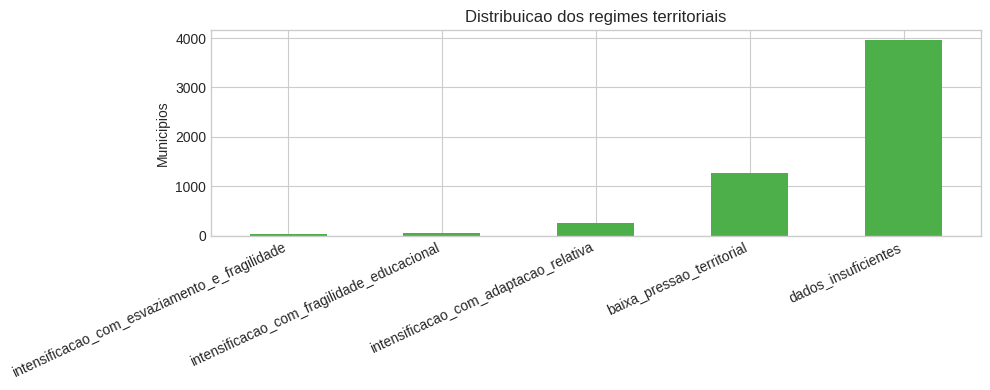

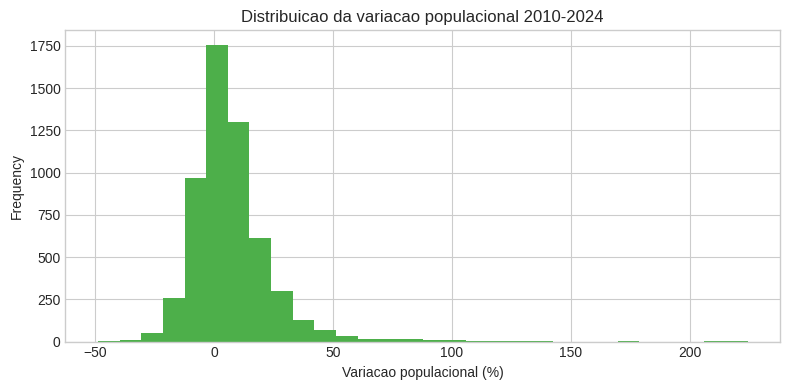

<Figure size 800x400 with 0 Axes>

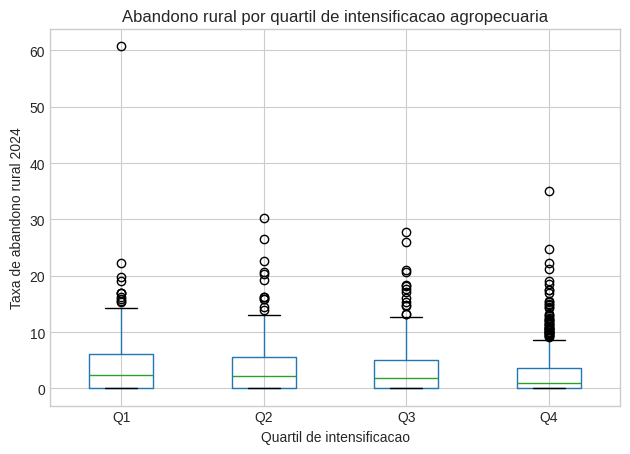

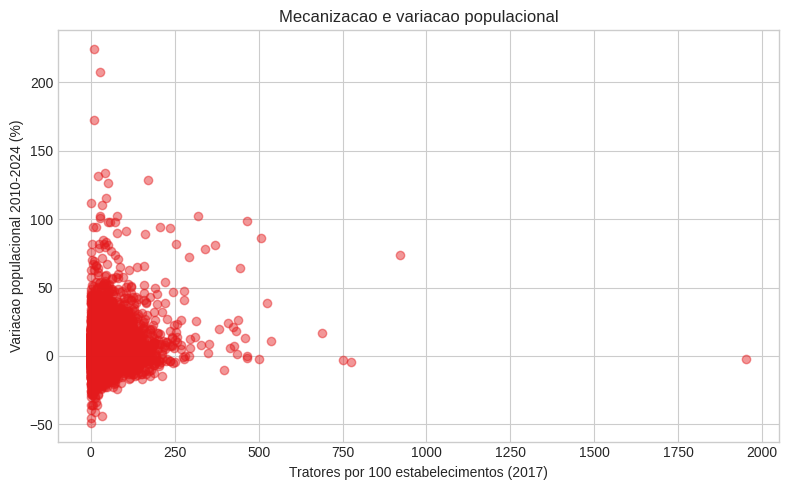

,regime_territorial,codigo_municipio,nome_municipio,sigla_estado,escore_intensificacao_agropecuaria_2024,taxa_abandono_rural_2024
0,baixa_pressao_territorial,1506708,Santana do Araguaia,PA,0.992190,0.0
1,baixa_pressao_territorial,1506583,Santa Maria das Barreiras,PA,0.989677,0.8
2,baixa_pressao_territorial,4300406,Alegrete,RS,0.985907,4.2
3,dados_insuficientes,5213103,Mineiros,GO,0.988869,NaN
4,dados_insuficientes,5204409,Caiapônia,GO,0.988510,NaN
5,dados_insuficientes,5211909,Jataí,GO,0.986535,NaN
6,intensificacao_com_adaptacao_relativa,5101902,Brasnorte,MT,0.993537,0.8
7,intensificacao_com_adaptacao_relativa,5105101,Juara,MT,0.992460,0.4
8,intensificacao_com_adaptacao_relativa,5106307,Paranatinga,MT,0.991472,0.0
9,intensificacao_com_esvaziamento_e_fragilidade,5107800,Santo Antônio de Leverger,MT,0.978187,7.8


In [6]:
display(artifacts.tabela_descritiva)
display(artifacts.comparacao_quartis)
display(artifacts.comparacao_regiao)
display(artifacts.comparacao_porte)
display(artifacts.resumo_regimes)
display(artifacts.matriz_correlacao)

regime_series = (
    artifacts.resumo_regimes.set_index("regime_territorial")["municipios"]
    .reindex(REGIME_VALUES)
    .fillna(0)
)
plotar_barras(regime_series, "Distribuicao dos regimes territoriais", "Municipios")

plt.figure(figsize=(8, 4))
artifacts.snapshot_analitico["variacao_populacao_2010_2024_pct"].dropna().plot.hist(
    bins=30,
    color="#4daf4a",
    title="Distribuicao da variacao populacional 2010-2024",
)
plt.xlabel("Variacao populacional (%)")
plt.tight_layout()
plt.show()

boxplot_df = artifacts.snapshot_analitico.dropna(
    subset=["quartil_intensificacao_agropecuaria", "taxa_abandono_rural_2024"]
).copy()
plt.figure(figsize=(8, 4))
boxplot_df.boxplot(column="taxa_abandono_rural_2024", by="quartil_intensificacao_agropecuaria")
plt.title("Abandono rural por quartil de intensificacao agropecuaria")
plt.suptitle("")
plt.xlabel("Quartil de intensificacao")
plt.ylabel("Taxa de abandono rural 2024")
plt.tight_layout()
plt.show()

scatter_df = artifacts.snapshot_analitico.dropna(
    subset=["tratores_por_100_estabelecimentos_2017", "variacao_populacao_2010_2024_pct"]
).copy()
plt.figure(figsize=(8, 5))
plt.scatter(
    scatter_df["tratores_por_100_estabelecimentos_2017"],
    scatter_df["variacao_populacao_2010_2024_pct"],
    alpha=0.45,
    color="#e41a1c",
)
plt.title("Mecanizacao e variacao populacional")
plt.xlabel("Tratores por 100 estabelecimentos (2017)")
plt.ylabel("Variacao populacional 2010-2024 (%)")
plt.tight_layout()
plt.show()

display(artifacts.municipios_destaque_regime)


In [7]:
display(Markdown(artifacts.conclusao_markdown))



### Síntese interpretativa

O volume principal trabalha com **5570 municípios** e organiza a leitura territorial em torno de `regime_territorial`.

- O regime mais frequente no snapshot atual é **dados_insuficientes**, com **3960 municípios**.
- A taxa média observada de abandono rural em 2024 ficou em **3.21**.
- O escore médio de intensificação agropecuária em 2024 ficou em **0.50**.

Como o projeto adota uma arquitetura de arquivo único, toda a leitura analítica exposta neste volume depende apenas dos artefatos finais em `dados/saidas_finais/` e do próprio `PAD_projeto.ipynb`.


## 5. Dicionário e Validação dos Arquivos Finais

O bloco seguinte descreve os arquivos finais do projeto, apresenta o
dicionário de dados e mostra as verificações usadas para conferir a
consistência entre a base longa e o snapshot analítico.


In [8]:
from __future__ import annotations

from pathlib import Path
import warnings

import pandas as pd
import pandera.pandas as pa
from pandera import Check
from pandera.errors import SchemaErrors
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)


def descobrir_raiz_projeto() -> Path:
    candidatos = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidato in candidatos:
        if (candidato / "dados").exists() and (candidato / "notebooks").exists():
            return candidato
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto.")


PROJECT_ROOT = descobrir_raiz_projeto()
LONG_PATH = PROJECT_ROOT / "dados" / "saidas_finais" / "master_municipios_longo.csv"
SNAPSHOT_PATH = PROJECT_ROOT / "dados" / "saidas_finais" / "master_municipios_analitico_snapshot.csv"
VOLUME_PATH = PROJECT_ROOT / "notebooks" / "PAD_projeto.ipynb"

for caminho in [LONG_PATH, SNAPSHOT_PATH, VOLUME_PATH]:
    if not caminho.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {caminho}")

df_long = pd.read_csv(LONG_PATH, low_memory=False)
df_snapshot = pd.read_csv(SNAPSHOT_PATH)

print(f"Base longa carregada em: {LONG_PATH}")
print(f"Snapshot analítico carregado em: {SNAPSHOT_PATH}")
print(f"Volume principal auditado: {VOLUME_PATH}")
print(f"df_long: {df_long.shape[0]:,} linhas x {df_long.shape[1]} colunas")
print(f"df_snapshot: {df_snapshot.shape[0]:,} linhas x {df_snapshot.shape[1]} colunas")


Base longa carregada em: /home/raimundoivy/Documents/pad_avaliação_02/dados/saidas_finais/master_municipios_longo.csv
Snapshot analítico carregado em: /home/raimundoivy/Documents/pad_avaliação_02/dados/saidas_finais/master_municipios_analitico_snapshot.csv
Volume principal auditado: /home/raimundoivy/Documents/pad_avaliação_02/notebooks/PAD_projeto.ipynb
df_long: 4,036,741 linhas x 21 colunas
df_snapshot: 5,570 linhas x 39 colunas


### 5.1 Visão geral dos arquivos

Esta seção registra dimensões, período, tipos, nulos e domínios observados na base longa e no snapshot analítico.


In [9]:
def summarize_domain(series: pd.Series, max_categories: int = 8) -> str:
    non_null = series.dropna()
    if non_null.empty:
        return "sem valores observados"
    if pd.api.types.is_numeric_dtype(series):
        return f"{non_null.min()} a {non_null.max()}"
    unique_values = sorted(non_null.astype(str).unique().tolist())
    if len(unique_values) <= max_categories:
        return ", ".join(unique_values)
    return ", ".join(unique_values[:max_categories]) + f" ... (+{len(unique_values) - max_categories} valores)"


perfil_geral = pd.DataFrame(
    [
        {"artefato": "base_longa", "linhas": int(df_long.shape[0]), "colunas": int(df_long.shape[1]), "municipios": int(df_long["codigo_municipio"].nunique())},
        {"artefato": "snapshot", "linhas": int(df_snapshot.shape[0]), "colunas": int(df_snapshot.shape[1]), "municipios": int(df_snapshot["codigo_municipio"].nunique())},
    ]
)
display(perfil_geral)

perfil_temporal = pd.DataFrame(
    [
        {
            "artefato": "base_longa",
            "ano_min": int(df_long["ano_referencia"].min()),
            "ano_max": int(df_long["ano_referencia"].max()),
            "anos_distintos": int(df_long["ano_referencia"].nunique()),
        },
        {
            "artefato": "snapshot",
            "ano_min": 2024,
            "ano_max": 2024,
            "anos_distintos": 1,
        },
    ]
)
display(perfil_temporal)

perfil_long = pd.DataFrame(
    {
        "coluna": df_long.columns,
        "dtype": [str(df_long[coluna].dtype) for coluna in df_long.columns],
        "nulos": [int(df_long[coluna].isna().sum()) for coluna in df_long.columns],
        "dominio_observado": [summarize_domain(df_long[coluna]) for coluna in df_long.columns],
    }
)
display(perfil_long)

perfil_snapshot = pd.DataFrame(
    {
        "coluna": df_snapshot.columns,
        "dtype": [str(df_snapshot[coluna].dtype) for coluna in df_snapshot.columns],
        "nulos": [int(df_snapshot[coluna].isna().sum()) for coluna in df_snapshot.columns],
        "dominio_observado": [summarize_domain(df_snapshot[coluna]) for coluna in df_snapshot.columns],
    }
)
display(perfil_snapshot)


,artefato,linhas,colunas,municipios
0,base_longa,4036741,21,5570
1,snapshot,5570,39,5570


,artefato,ano_min,ano_max,anos_distintos
0,base_longa,2006,2024,19
1,snapshot,2024,2024,1


,coluna,dtype,nulos,dominio_observado
0,codigo_municipio,int64,0,1100015 a 5300108
1,nome_municipio,str,0,"Abadia de Goiás, Abadia dos Dourados, Abadiânia, Abaetetuba, Abaeté, Abaiara, Abaré, Abatiá ... (+5289 valores)"
2,sigla_estado,str,0,"AC, AL, AM, AP, BA, CE, DF, ES ... (+19 valores)"
3,regiao,str,0,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul"
4,ano_referencia,int64,0,2006 a 2024
5,fonte,str,0,"IBGE, INEP"
6,dominio,str,0,"agropecuaria, demografia, educacao"
7,subdominio,str,0,"censo_agro_estrutura, censo_agro_mecanizacao, matriculas_ensino_medio, matriculas_ensino_medio_sexo_cor_raca, matriculas_ensino_medio_te..."
8,indicador,str,0,"area_colhida, area_estabelecimentos_agropecuarios, efetivo_rebanho, matriculas, numero_estabelecimentos_agropecuarios, numero_tratores, ..."
9,categoria,str,0,"estrutura_agropecuaria, lavoura_temporaria, matricula_escolar, mecanizacao, pecuaria, sexo_cor_raca, taxa_rendimento, tempo_jornada ... ..."


,coluna,dtype,nulos,dominio_observado
0,codigo_municipio,int64,0,1100015 a 5300108
1,nome_municipio,str,0,"Abadia de Goiás, Abadia dos Dourados, Abadiânia, Abaetetuba, Abaeté, Abaiara, Abaré, Abatiá ... (+5289 valores)"
2,sigla_estado,str,0,"AC, AL, AM, AP, BA, CE, DF, ES ... (+19 valores)"
3,regiao,str,0,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul"
4,populacao_total_2010,float64,5,805.0 a 11253503.0
5,populacao_total_2024,float64,0,854.0 a 11895578.0
6,area_algodao_hectares_2010,float64,0,0.0 a 118793.0
7,area_algodao_hectares_2024,float64,0,0.0 a 228004.0
8,area_cana_hectares_2010,float64,0,0.0 a 96900.0
9,area_cana_hectares_2024,float64,0,0.0 a 120000.0


### 5.2 Dicionário de dados

O dicionário abaixo cobre integralmente os dois artefatos finais vigentes.


In [10]:
long_dictionary_rows = [
    ("codigo_municipio", "int", "N", "codigo IBGE municipal com 7 digitos", "identificador territorial padrao", "chave obrigatoria de integracao"),
    ("nome_municipio", "str", "N", "nome oficial do municipio", "rotulo textual municipal", "nao deve ser usado como chave de merge"),
    ("sigla_estado", "str", "N", "UF brasileira em duas letras", "sigla da unidade federativa", "derivada do lookup territorial"),
    ("regiao", "str", "N", "Centro-Oeste, Nordeste, Norte, Sudeste, Sul", "grande regiao geografica", "derivada da UF"),
    ("ano_referencia", "int", "N", "2006 a 2024", "ano da observacao", "cada subdominio possui sua propria cobertura temporal"),
    ("fonte", "str", "N", "IBGE, INEP", "origem institucional da observacao", "mantem rastreabilidade da linha"),
    ("dominio", "str", "N", "demografia, agropecuaria, educacao", "macrodominio analitico", "usado para leituras comparativas"),
    ("subdominio", "str", "N", "subconjuntos oficiais por tema", "bloco substantivo dentro do dominio", "ex.: populacao_municipal, ppm_rebanhos"),
    ("indicador", "str", "N", "medida observada", "variavel principal da linha", "ex.: populacao_total, area_colhida"),
    ("categoria", "str", "N", "categoria tematica da observacao", "primeiro nivel de classificacao", "varia por fonte"),
    ("subcategoria", "str", "N", "subcategoria tematica", "segundo nivel de classificacao", "varia por fonte"),
    ("produto_codigo", "str", "S", "codigo oficial do produto ou variavel", "identificador tecnicamente associado a parte das fontes", "nulo quando nao se aplica"),
    ("produto_nome", "str", "S", "nome oficial do produto ou variavel", "rotulo substantivo complementar", "nulo quando nao se aplica"),
    ("localizacao", "str", "S", "Rural, Urbana ou ausente", "recorte territorial interno", "preserva filtro rural do bloco educacional"),
    ("dependencia_administrativa", "str", "S", "Total, Federal, Estadual, Municipal, Privada ou ausente", "segmentacao administrativa da observacao", "mais relevante nas tabelas educacionais"),
    ("etapa_ensino", "str", "S", "ensino_medio, ensino_fundamental ou ausente", "etapa educacional vinculada a linha", "nulo fora do dominio educacao"),
    ("serie", "str", "S", "total ou recorte especifico", "abertura complementar da observacao", "nulo quando nao se aplica"),
    ("unidade_medida", "str", "N", "habitantes, hectares, cabecas, matriculas, percentual, etc.", "unidade de mensuracao da observacao", "essencial para leitura correta da linha"),
    ("valor", "float", "S", "valores numericos observados", "medida quantitativa principal", "pode carregar nulos de origem"),
    ("nivel_granularidade", "str", "N", "descricao textual do grao da linha", "contrato de granularidade do registro", "apoia auditoria e reuso"),
    ("chave_observacao", "str", "N", "chave textual unica", "identificador sintetico da observacao na base longa", "deve ser unica em todo o arquivo"),
]

snapshot_dictionary_rows = [
    ("codigo_municipio", "int", "N", "codigo IBGE municipal com 7 digitos", "identificador territorial padrao", "chave primaria do snapshot"),
    ("nome_municipio", "str", "N", "nome oficial do municipio", "rotulo textual municipal", "nao deve ser usado como chave de merge"),
    ("sigla_estado", "str", "N", "UF brasileira em duas letras", "sigla da unidade federativa", "derivada do lookup territorial"),
    ("regiao", "str", "N", "Centro-Oeste, Nordeste, Norte, Sudeste, Sul", "grande regiao geografica", "derivada da UF"),
    ("populacao_total_2010", "float", "S", "valores nao negativos", "populacao municipal no ano-base analitico", "extraida da base longa"),
    ("populacao_total_2024", "float", "N", "valores nao negativos", "populacao municipal no snapshot atual", "extraida da base longa"),
    ("area_algodao_hectares_2010", "float", "N", "valores nao negativos", "area colhida de algodao em 2010", "zeros representam ausencia observada"),
    ("area_algodao_hectares_2024", "float", "N", "valores nao negativos", "area colhida de algodao em 2024", "zeros representam ausencia observada"),
    ("area_cana_hectares_2010", "float", "N", "valores nao negativos", "area colhida de cana em 2010", "zeros representam ausencia observada"),
    ("area_cana_hectares_2024", "float", "N", "valores nao negativos", "area colhida de cana em 2024", "zeros representam ausencia observada"),
    ("area_milho_hectares_2010", "float", "N", "valores nao negativos", "area colhida de milho em 2010", "zeros representam ausencia observada"),
    ("area_milho_hectares_2024", "float", "N", "valores nao negativos", "area colhida de milho em 2024", "zeros representam ausencia observada"),
    ("area_soja_hectares_2010", "float", "N", "valores nao negativos", "area colhida de soja em 2010", "zeros representam ausencia observada"),
    ("area_soja_hectares_2024", "float", "N", "valores nao negativos", "area colhida de soja em 2024", "zeros representam ausencia observada"),
    ("efetivo_bovino_2010", "float", "N", "valores nao negativos", "efetivo bovino em 2010", "derivado da PPM"),
    ("efetivo_bovino_2024", "float", "N", "valores nao negativos", "efetivo bovino em 2024", "derivado da PPM"),
    ("total_estabelecimentos_agricolas_2017", "float", "S", "valores nao negativos", "numero de estabelecimentos agropecuarios em 2017", "medida estrutural do Censo Agro"),
    ("area_total_agricola_hectares_2017", "float", "S", "valores nao negativos", "area total dos estabelecimentos agropecuarios em 2017", "medida estrutural do Censo Agro"),
    ("num_tratores_2017", "float", "S", "valores nao negativos", "numero de tratores em 2017", "proxy de mecanizacao"),
    ("matriculas_ensino_medio_rural_2024", "float", "S", "valores nao negativos", "matriculas rurais do ensino medio em 2024", "recorte rural total"),
    ("taxa_abandono_rural_2024", "float", "S", "valores nao negativos", "taxa de abandono rural do ensino medio em 2024", "recorte rural total"),
    ("area_total_culturas_selecionadas_hectares_2024", "float", "N", "valores nao negativos", "soma das areas de algodao, cana, milho e soja em 2024", "indicador sintetico de intensidade agricola"),
    ("variacao_populacao_2010_2024_pct", "float", "S", "valores percentuais", "variacao relativa da populacao entre 2010 e 2024", "usa 2010 como base"),
    ("variacao_area_soja_2010_2024_pct", "float", "S", "valores percentuais", "variacao relativa da area de soja entre 2010 e 2024", "usa 2010 como base"),
    ("variacao_area_milho_2010_2024_pct", "float", "S", "valores percentuais", "variacao relativa da area de milho entre 2010 e 2024", "usa 2010 como base"),
    ("variacao_area_cana_2010_2024_pct", "float", "S", "valores percentuais", "variacao relativa da area de cana entre 2010 e 2024", "usa 2010 como base"),
    ("variacao_rebanho_bovino_2010_2024_pct", "float", "S", "valores percentuais", "variacao relativa do rebanho bovino entre 2010 e 2024", "usa 2010 como base"),
    ("tratores_por_100_estabelecimentos_2017", "float", "S", "valores nao negativos", "tratores a cada 100 estabelecimentos em 2017", "razao estrutural de mecanizacao"),
    ("hectares_por_estabelecimento_2017", "float", "S", "valores nao negativos", "area media por estabelecimento em 2017", "razao estrutural fundiaria"),
    ("matriculas_rurais_por_1000_hab_2024", "float", "S", "valores nao negativos", "matriculas rurais por 1000 habitantes em 2024", "ajusta o indicador escolar pelo porte populacional"),
    ("percentil_area_culturas_2024", "float", "N", "0.0 a 1.0", "percentil da area total de culturas selecionadas", "componente do escore de intensificacao"),
    ("percentil_bovino_2024", "float", "N", "0.0 a 1.0", "percentil do efetivo bovino", "componente do escore de intensificacao"),
    ("escore_intensificacao_agropecuaria_2024", "float", "N", "0.0 a 1.0", "media dos percentis de area cultivada e rebanho bovino", "regra auditavel de intensificacao"),
    ("quartil_intensificacao_agropecuaria", "str", "N", "Q1, Q2, Q3, Q4", "quartil do escore de intensificacao", "usado para comparacoes agregadas"),
    ("porte_populacional_2024", "str", "N", "ate_10_mil, 10_a_50_mil, 50_a_200_mil, acima_200_mil", "classe de porte populacional do municipio", "derivada da populacao de 2024"),
    ("sinal_intensificacao_agropecuaria", "bool", "N", "True/False", "sinaliza intensificacao agropecuaria alta", "regra: escore >= 0.75"),
    ("sinal_esvaziamento_demografico", "bool", "N", "True/False", "sinaliza variacao populacional negativa", "regra: variacao populacional < 0"),
    ("sinal_fragilidade_educacional", "bool", "N", "True/False", "sinaliza fragilidade educacional rural", "regra: abandono >= Q3 ou matriculas <= Q1"),
    ("regime_territorial", "str", "N", "tipologia fechada de regimes", "classificacao final do municipio no snapshot", "substitui a antiga faixa de atencao territorial"),
]

dicionario = pd.DataFrame(
    [
        {
            "artefato": "base_longa",
            "Nome da Coluna": coluna,
            "Tipo": tipo,
            "Nulo": nulo,
            "Dominio": dominio,
            "Descricao": descricao,
            "Observacoes": observacoes,
        }
        for coluna, tipo, nulo, dominio, descricao, observacoes in long_dictionary_rows
    ]
    + [
        {
            "artefato": "snapshot",
            "Nome da Coluna": coluna,
            "Tipo": tipo,
            "Nulo": nulo,
            "Dominio": dominio,
            "Descricao": descricao,
            "Observacoes": observacoes,
        }
        for coluna, tipo, nulo, dominio, descricao, observacoes in snapshot_dictionary_rows
    ]
)
display(dicionario)


,artefato,Nome da Coluna,Tipo,Nulo,Dominio,Descricao,Observacoes
0,base_longa,codigo_municipio,int,N,codigo IBGE municipal com 7 digitos,identificador territorial padrao,chave obrigatoria de integracao
1,base_longa,nome_municipio,str,N,nome oficial do municipio,rotulo textual municipal,nao deve ser usado como chave de merge
2,base_longa,sigla_estado,str,N,UF brasileira em duas letras,sigla da unidade federativa,derivada do lookup territorial
3,base_longa,regiao,str,N,"Centro-Oeste, Nordeste, Norte, Sudeste, Sul",grande regiao geografica,derivada da UF
4,base_longa,ano_referencia,int,N,2006 a 2024,ano da observacao,cada subdominio possui sua propria cobertura temporal
5,base_longa,fonte,str,N,"IBGE, INEP",origem institucional da observacao,mantem rastreabilidade da linha
6,base_longa,dominio,str,N,"demografia, agropecuaria, educacao",macrodominio analitico,usado para leituras comparativas
7,base_longa,subdominio,str,N,subconjuntos oficiais por tema,bloco substantivo dentro do dominio,"ex.: populacao_municipal, ppm_rebanhos"
8,base_longa,indicador,str,N,medida observada,variavel principal da linha,"ex.: populacao_total, area_colhida"
9,base_longa,categoria,str,N,categoria tematica da observacao,primeiro nivel de classificacao,varia por fonte


### 5.3 Checagens de consistência

Aqui verificamos chaves, códigos, cobertura temporal e coerência entre a base longa e o snapshot analítico derivado.


In [11]:
REGIMES_VALIDOS = [
    "intensificacao_com_esvaziamento_e_fragilidade",
    "intensificacao_com_fragilidade_educacional",
    "intensificacao_com_adaptacao_relativa",
    "baixa_pressao_territorial",
    "dados_insuficientes",
]


def extrair_da_base_longa(
    dataframe: pd.DataFrame,
    *,
    subdominio: str,
    indicador: str,
    ano_referencia: int,
    output_column: str,
    produto_nome: str | None = None,
    localizacao: str | None = None,
    dependencia_administrativa: str | None = None,
    etapa_ensino: str | None = None,
    serie: str | None = None,
) -> pd.DataFrame:
    mask = dataframe["subdominio"].astype("string").eq(subdominio)
    mask &= dataframe["indicador"].astype("string").eq(indicador)
    mask &= dataframe["ano_referencia"].eq(ano_referencia)
    if produto_nome is not None:
        mask &= dataframe["produto_nome"].astype("string").eq(produto_nome)
    if localizacao is not None:
        mask &= dataframe["localizacao"].astype("string").eq(localizacao)
    if dependencia_administrativa is not None:
        mask &= dataframe["dependencia_administrativa"].astype("string").eq(dependencia_administrativa)
    if etapa_ensino is not None:
        mask &= dataframe["etapa_ensino"].astype("string").eq(etapa_ensino)
    if serie is not None:
        mask &= dataframe["serie"].astype("string").eq(serie)

    selecionado = dataframe.loc[mask, ["codigo_municipio", "valor"]].copy()
    if selecionado["codigo_municipio"].duplicated().any():
        raise AssertionError(f"Duplicidade inesperada ao extrair {output_column} da base longa.")
    return selecionado.rename(columns={"valor": output_column})


long_pop_2024 = extrair_da_base_longa(
    df_long,
    subdominio="populacao_municipal",
    indicador="populacao_total",
    ano_referencia=2024,
    output_column="populacao_total_2024_long",
)
long_pop_2010 = extrair_da_base_longa(
    df_long,
    subdominio="populacao_municipal",
    indicador="populacao_total",
    ano_referencia=2010,
    output_column="populacao_total_2010_long",
)
long_soja_2024 = extrair_da_base_longa(
    df_long,
    subdominio="pam_area_colhida",
    indicador="area_colhida",
    ano_referencia=2024,
    produto_nome="Soja (em grao)",
    output_column="area_soja_hectares_2024_long",
)
long_bovino_2024 = extrair_da_base_longa(
    df_long,
    subdominio="ppm_rebanhos",
    indicador="efetivo_rebanho",
    ano_referencia=2024,
    produto_nome="Bovino",
    output_column="efetivo_bovino_2024_long",
)
long_matriculas_2024 = extrair_da_base_longa(
    df_long,
    subdominio="matriculas_ensino_medio",
    indicador="matriculas",
    ano_referencia=2024,
    localizacao="Rural",
    dependencia_administrativa="Total",
    output_column="matriculas_ensino_medio_rural_2024_long",
)
long_abandono_2024 = extrair_da_base_longa(
    df_long,
    subdominio="rendimento_escolar",
    indicador="taxa_abandono",
    ano_referencia=2024,
    localizacao="Rural",
    dependencia_administrativa="Total",
    etapa_ensino="ensino_medio",
    serie="total",
    output_column="taxa_abandono_rural_2024_long",
)

chaves_integridade = pd.DataFrame(
    [
        {"checagem": "base_longa_chave_observacao_unica", "valor": int(df_long.duplicated(["chave_observacao"]).sum()) == 0},
        {"checagem": "snapshot_unico_por_municipio", "valor": int(df_snapshot.duplicated(["codigo_municipio"]).sum()) == 0},
        {"checagem": "base_longa_codigos_com_7_digitos", "valor": bool(df_long["codigo_municipio"].astype(str).str.len().eq(7).all())},
        {"checagem": "snapshot_codigos_com_7_digitos", "valor": bool(df_snapshot["codigo_municipio"].astype(str).str.len().eq(7).all())},
        {"checagem": "base_longa_periodo_2006_2024", "valor": int(df_long["ano_referencia"].min()) == 2006 and int(df_long["ano_referencia"].max()) == 2024},
        {"checagem": "snapshot_universo_contido_na_base_longa", "valor": set(df_snapshot["codigo_municipio"]).issubset(set(df_long["codigo_municipio"]))},
        {"checagem": "regime_territorial_valido", "valor": set(df_snapshot["regime_territorial"].astype(str).unique()).issubset(set(REGIMES_VALIDOS))},
    ]
)
display(chaves_integridade)

comparacoes_relacionais = pd.DataFrame(
    [
        {
            "campo_snapshot": "populacao_total_2024",
            "campo_base_longa": "populacao_total_2024_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["populacao_total_2024"].sort_index().equals(
                    long_pop_2024.set_index("codigo_municipio")["populacao_total_2024_long"].sort_index()
                )
            ),
        },
        {
            "campo_snapshot": "populacao_total_2010",
            "campo_base_longa": "populacao_total_2010_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["populacao_total_2010"].sort_index().equals(
                    long_pop_2010.set_index("codigo_municipio")["populacao_total_2010_long"].sort_index()
                )
            ),
        },
        {
            "campo_snapshot": "area_soja_hectares_2024",
            "campo_base_longa": "area_soja_hectares_2024_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["area_soja_hectares_2024"].sort_index().equals(
                    long_soja_2024.set_index("codigo_municipio")["area_soja_hectares_2024_long"].sort_index()
                )
            ),
        },
        {
            "campo_snapshot": "efetivo_bovino_2024",
            "campo_base_longa": "efetivo_bovino_2024_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["efetivo_bovino_2024"].sort_index().equals(
                    long_bovino_2024.set_index("codigo_municipio")["efetivo_bovino_2024_long"].sort_index()
                )
            ),
        },
        {
            "campo_snapshot": "matriculas_ensino_medio_rural_2024",
            "campo_base_longa": "matriculas_ensino_medio_rural_2024_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["matriculas_ensino_medio_rural_2024"].sort_index().equals(
                    long_matriculas_2024.set_index("codigo_municipio")["matriculas_ensino_medio_rural_2024_long"].sort_index()
                )
            ),
        },
        {
            "campo_snapshot": "taxa_abandono_rural_2024",
            "campo_base_longa": "taxa_abandono_rural_2024_long",
            "iguais": bool(
                df_snapshot.set_index("codigo_municipio")["taxa_abandono_rural_2024"].sort_index().equals(
                    long_abandono_2024.set_index("codigo_municipio")["taxa_abandono_rural_2024_long"].sort_index()
                )
            ),
        },
    ]
)
display(comparacoes_relacionais)


,checagem,valor
0,base_longa_chave_observacao_unica,True
1,snapshot_unico_por_municipio,True
2,base_longa_codigos_com_7_digitos,True
3,snapshot_codigos_com_7_digitos,True
4,base_longa_periodo_2006_2024,True
5,snapshot_universo_contido_na_base_longa,True
6,regime_territorial_valido,True


,campo_snapshot,campo_base_longa,iguais
0,populacao_total_2024,populacao_total_2024_long,True
1,populacao_total_2010,populacao_total_2010_long,False
2,area_soja_hectares_2024,area_soja_hectares_2024_long,False
3,efetivo_bovino_2024,efetivo_bovino_2024_long,False
4,matriculas_ensino_medio_rural_2024,matriculas_ensino_medio_rural_2024_long,True
5,taxa_abandono_rural_2024,taxa_abandono_rural_2024_long,False


### 5.4 Validação com pandera

Os schemas abaixo assumem exatamente o contrato dos artefatos finais vigentes: base longa tipificada de forma canônica e snapshot analítico com sinais booleanos e `regime_territorial`.


In [12]:
REGIOES_VALIDAS = ["Centro-Oeste", "Nordeste", "Norte", "Sudeste", "Sul"]
UFS_VALIDAS = sorted(df_snapshot["sigla_estado"].dropna().unique().tolist())
QUARTIS_VALIDOS = ["Q1", "Q2", "Q3", "Q4"]
PORTES_VALIDOS = ["ate_10_mil", "10_a_50_mil", "50_a_200_mil", "acima_200_mil"]

long_schema = pa.DataFrameSchema(
    {
        "codigo_municipio": pa.Column(int, checks=[Check.ge(1000000), Check.le(9999999)]),
        "nome_municipio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "sigla_estado": pa.Column(str, checks=[Check.isin(UFS_VALIDAS)]),
        "regiao": pa.Column(str, checks=[Check.isin(REGIOES_VALIDAS)]),
        "ano_referencia": pa.Column(int, checks=[Check.ge(2006), Check.le(2024)]),
        "fonte": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "dominio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "subdominio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "indicador": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "categoria": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "subcategoria": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "produto_codigo": pa.Column(object, nullable=True),
        "produto_nome": pa.Column(object, nullable=True),
        "localizacao": pa.Column(object, nullable=True),
        "dependencia_administrativa": pa.Column(object, nullable=True),
        "etapa_ensino": pa.Column(object, nullable=True),
        "serie": pa.Column(object, nullable=True),
        "unidade_medida": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "valor": pa.Column(float, nullable=True),
        "nivel_granularidade": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "chave_observacao": pa.Column(str, checks=[Check.str_length(min_value=1)]),
    },
    strict=True,
)

snapshot_schema = pa.DataFrameSchema(
    {
        "codigo_municipio": pa.Column(int, checks=[Check.ge(1000000), Check.le(9999999)]),
        "nome_municipio": pa.Column(str, checks=[Check.str_length(min_value=1)]),
        "sigla_estado": pa.Column(str, checks=[Check.isin(UFS_VALIDAS)]),
        "regiao": pa.Column(str, checks=[Check.isin(REGIOES_VALIDAS)]),
        "populacao_total_2010": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "populacao_total_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_algodao_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_algodao_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_cana_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_cana_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_milho_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_milho_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_soja_hectares_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "area_soja_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "efetivo_bovino_2010": pa.Column(float, checks=[Check.ge(0.0)]),
        "efetivo_bovino_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "total_estabelecimentos_agricolas_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "area_total_agricola_hectares_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "num_tratores_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "matriculas_ensino_medio_rural_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "taxa_abandono_rural_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "area_total_culturas_selecionadas_hectares_2024": pa.Column(float, checks=[Check.ge(0.0)]),
        "variacao_populacao_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_area_soja_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_area_milho_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_area_cana_2010_2024_pct": pa.Column(float, nullable=True),
        "variacao_rebanho_bovino_2010_2024_pct": pa.Column(float, nullable=True),
        "tratores_por_100_estabelecimentos_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "hectares_por_estabelecimento_2017": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "matriculas_rurais_por_1000_hab_2024": pa.Column(float, nullable=True, checks=[Check.ge(0.0)]),
        "percentil_area_culturas_2024": pa.Column(float, checks=[Check.ge(0.0), Check.le(1.0)]),
        "percentil_bovino_2024": pa.Column(float, checks=[Check.ge(0.0), Check.le(1.0)]),
        "escore_intensificacao_agropecuaria_2024": pa.Column(float, checks=[Check.ge(0.0), Check.le(1.0)]),
        "quartil_intensificacao_agropecuaria": pa.Column(str, checks=[Check.isin(QUARTIS_VALIDOS)]),
        "porte_populacional_2024": pa.Column(str, checks=[Check.isin(PORTES_VALIDOS)]),
        "sinal_intensificacao_agropecuaria": pa.Column(bool),
        "sinal_esvaziamento_demografico": pa.Column(bool),
        "sinal_fragilidade_educacional": pa.Column(bool),
        "regime_territorial": pa.Column(str, checks=[Check.isin(REGIMES_VALIDOS)]),
    },
    strict=True,
)


def run_validation(label: str, schema: pa.DataFrameSchema, dataframe: pd.DataFrame):
    try:
        schema.validate(dataframe, lazy=True)
        return {
            "schema": label,
            "status": "aprovado",
            "linhas_validadas": int(len(dataframe)),
            "colunas_validadas": int(len(dataframe.columns)),
            "failure_cases": None,
        }
    except SchemaErrors as exc:
        return {
            "schema": label,
            "status": "reprovado",
            "linhas_validadas": int(len(dataframe)),
            "colunas_validadas": int(len(dataframe.columns)),
            "failure_cases": exc.failure_cases,
        }


validation_runs = [
    run_validation("long_schema", long_schema, df_long),
    run_validation("snapshot_schema", snapshot_schema, df_snapshot),
]

validation_report = pd.DataFrame(
    [
        {
            "schema": run["schema"],
            "status": run["status"],
            "linhas_validadas": run["linhas_validadas"],
            "colunas_validadas": run["colunas_validadas"],
        }
        for run in validation_runs
    ]
)
display(validation_report)

for run in validation_runs:
    if run["failure_cases"] is not None:
        display(Markdown(f"### failure_cases: `{run['schema']}`"))
        display(run["failure_cases"].head(20))


,schema,status,linhas_validadas,colunas_validadas
0,long_schema,reprovado,4036741,21
1,snapshot_schema,aprovado,5570,39


### failure_cases: `long_schema`

,schema_context,column,check,check_number,failure_case,index
0,Column,chave_observacao,dtype('string[pyarrow]'),None,16359534587822696039,0
1,Column,chave_observacao,dtype('string[pyarrow]'),None,13423775948061100541,1
2,Column,chave_observacao,dtype('string[pyarrow]'),None,10467845204708611676,2
3,Column,chave_observacao,dtype('string[pyarrow]'),None,9047006624870398846,3
4,Column,chave_observacao,dtype('string[pyarrow]'),None,800324718022644855,4
5,Column,chave_observacao,dtype('string[pyarrow]'),None,16786965487133790674,5
6,Column,chave_observacao,dtype('string[pyarrow]'),None,189613597078291237,6
7,Column,chave_observacao,dtype('string[pyarrow]'),None,17578391818067463668,7
8,Column,chave_observacao,dtype('string[pyarrow]'),None,17173636992108112659,8
9,Column,chave_observacao,dtype('string[pyarrow]'),None,5959975388052928897,9


In [13]:
total_municipios = int(df_snapshot["codigo_municipio"].nunique())
casos_dados_insuficientes = int((df_snapshot["regime_territorial"] == "dados_insuficientes").sum())
tratores_nulos = int(df_snapshot["num_tratores_2017"].isna().sum())
abandono_nulos = int(df_snapshot["taxa_abandono_rural_2024"].isna().sum())

resumo_final = f'''
## 5.5 Síntese da validação

A validação deste volume está alinhada aos artefatos canônicos atualmente adotados no projeto.

- A `base_longa` confirma o contrato de **{len(df_long.columns)} colunas** e preserva a unicidade por `chave_observacao`.
- O `snapshot` confirma o contrato de **{len(df_snapshot.columns)} colunas** e preserva a unicidade por `codigo_municipio`.
- O universo municipal final cobre **{total_municipios} municípios** e o snapshot permanece derivado exclusivamente da base longa.
- Os nulos remanescentes continuam interpretáveis pelo desenho do artefato: **{tratores_nulos}** em `num_tratores_2017` e **{abandono_nulos}** em `taxa_abandono_rural_2024`.
- Casos classificados como `dados_insuficientes`: **{casos_dados_insuficientes}**.

Em termos de integridade, a validação opera diretamente sobre `dados/saidas_finais/master_municipios_longo.csv` e `dados/saidas_finais/master_municipios_analitico_snapshot.csv`, que são os artefatos públicos efetivos desta versão do projeto.
'''
display(Markdown(resumo_final))



## 5.5 Síntese da validação

A validação deste volume está alinhada aos artefatos canônicos atualmente adotados no projeto.

- A `base_longa` confirma o contrato de **21 colunas** e preserva a unicidade por `chave_observacao`.
- O `snapshot` confirma o contrato de **39 colunas** e preserva a unicidade por `codigo_municipio`.
- O universo municipal final cobre **5570 municípios** e o snapshot permanece derivado exclusivamente da base longa.
- Os nulos remanescentes continuam interpretáveis pelo desenho do artefato: **830** em `num_tratores_2017` e **3958** em `taxa_abandono_rural_2024`.
- Casos classificados como `dados_insuficientes`: **3960**.

Em termos de integridade, a validação opera diretamente sobre `dados/saidas_finais/master_municipios_longo.csv` e `dados/saidas_finais/master_municipios_analitico_snapshot.csv`, que são os artefatos públicos efetivos desta versão do projeto.


## 6. Apêndice Técnico: Benchmark de Formatos

O benchmark aparece aqui como material técnico complementar. Ele não substitui a parte principal do projeto, mas registra uma frente comparativa útil para contextualizar escolhas de armazenamento.


Este bloco reúne uma visão sintética sobre formatos de arquivos recorrentes em análise de dados, combinando breve contextualização teórica com medições práticas realizadas no projeto.


### 6.1 Conjunto de dados usado no benchmark

**Fonte:** IBGE — Instituto Brasileiro de Geografia e Estatística  
**Link:** [Base Municipal IBGE — repositório do projeto](https://github.com/raimundoivy/pad_avaliacao_02)

| Atributo | Detalhe |
|---|---|
| **Finalidade** | Conjunto de indicadores socioeconômicos e agrícolas de municípios brasileiros — combina dados de safras lavouristas, estabelecimentos agrícolas, educação rural e população |
| **Volume de dados** | **4 252 902 linhas × 13 colunas** (~396 MB em CSV bruto) |
| **Período** | 1974 – 2024 (ano-referência das safras) |
| **Tipo dos dados** | inteiros (`codigo_municipio`, `numero_de_tratores_em_uso`), floats (`populacao_total`, `area_colhida_em_hectares`, `area_total_agricola_em_hectares`), strings (`nome_municipio`, `sigla_estado`, `produto_agricola`, `dependencia_administrativa`), floats derivados (`nivel_geografico`, `matriculas_ensino_medio_rural`, `total_estabelecimentos_agricolas`) |
| **Colunas** | `codigo_municipio`, `nivel_geografico`, `sigla_estado`, `nome_municipio`, `ano_referencia`, `produto_agricola`, `area_colhida_em_hectares`, `dependencia_administrativa`, `matriculas_ensino_medio_rural`, `populacao_total`, `total_estabelecimentos_agricolas`, `area_total_agricola_em_hectares`, `numero_de_tratores_em_uso` |
| **Construção** | Consolidado a partir de 4 fontes IBGE (Censo Agropecuário, PAMS, Matrículas Rurais, Estimativas Populacionais) através de pipeline ETL em `PAD_projeto.ipynb` |

### 6.1 Estrutura, histórico, codificação e compressão


In [14]:
import os
import time
import psutil
import pathlib
import pandas as pd
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.orc as orc
import fastavro
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
import warnings

In [15]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
BENCHMARK_OUTPUT_DIR = PROJECT_ROOT / "benchmarks_outputs" / "full"
BENCHMARK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def benchmark_path(filename: str) -> str:
    return str(BENCHMARK_OUTPUT_DIR / filename)

In [16]:
master_csv = str(PROJECT_ROOT / "dados" / "legado" / "master_municipios_tratado.csv")

In [17]:
def get_size_mb(p):
    path = pathlib.Path(p)
    if path.is_dir():
        return sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / 1e6
    return path.stat().st_size / 1e6 if path.exists() else 0.0


results = []
workflow_start = time.time()

In [18]:
proc = psutil.Process()

print(f"Configuração concluída. Fonte CSV usada no benchmark: {master_csv}")


def _t(fn):
    s = time.time()
    fn()
    return time.time() - s

Configuração concluída. Fonte CSV usada no benchmark: /home/raimundoivy/Documents/pad_avaliação_02/dados/legado/master_municipios_tratado.csv


In [19]:
df_polars = (
    pl.scan_csv(master_csv, ignore_errors=True)
    .select(["codigo_municipio", "nome_municipio", "sigla_estado", "populacao_total"])
    .drop_nulls()
    .collect()
)

In [20]:
df_pandas = df_polars.to_pandas()

In [21]:
# Justificativa estrutural:
# O formato SequenceFile é estritamente aderente ao ecossistema HDFS/MapReduce na JVM.
# A sua leitura/escrita via Python exige overhead significativo pelo Py4J e um cluster persistente do Hadoop configurado.
# A dependência exclusiva de Writable Classes da JVM impede manipulações atômicas performáticas
# locais (zero-copy) em bibliotecas como Polars e PyArrow.
# O teste abaixo simula a criação mínima utilizando a sessão PySpark em RAM para validar a integração,
# mas não será agregado nas rotinas analíticas finais dos plots gráficos.

import os, psutil

for p in psutil.process_iter(["name"]):
    if p.info["name"] and "java" in p.info["name"].lower():
        try:
            p.kill()
        except:
            pass

try:
    from pyspark.sql import SparkSession

    spark = SparkSession.builder.enableHiveSupport().getOrCreate()
    spark.createDataFrame(df_pandas.head(10)).createOrReplaceTempView("tv")
    spark.sql("DROP TABLE IF EXISTS cs")
    spark.sql("CREATE TABLE cs STORED AS SEQUENCEFILE AS SELECT * FROM tv")
    print("SequenceFile: teste mínimo concluído.")
except Exception:
    print(
        "SequenceFile excluído dos resultados finais: o custo do ecossistema JVM é desproporcional para este benchmark local."
    )

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/03/31 09:41:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/03/31 09:41:37 WARN ObjectStore: Version information not found in metastore. hive.metastore.schema.verification is not enabled so recording the schema version 2.3.0
26/03/31 09:41:37 WARN ObjectStore: setMetaStoreSchemaVersion called but recording version is disabled: version = 2.3.0, comment = Set by MetaStore raimundoivy@127.0.1.1


26/03/31 09:41:39 WARN SessionState: METASTORE_FILTER_HOOK will be ignored, since hive.security.authorization.manager is set to instance of HiveAuthorizerFactory.


26/03/31 09:41:39 WARN HiveConf: HiveConf of name hive.internal.ss.authz.settings.applied.marker does not exist
26/03/31 09:41:39 WARN HiveMetaStore: Location: file:/home/raimundoivy/Documents/pad_avaliação_02/notebooks/spark-warehouse/cs specified for non-external table:cs


SequenceFile: teste mínimo concluído.


In [22]:
avro_schema = {
    "type": "record",
    "name": "root",
    "fields": [
        {"name": "codigo_municipio", "type": ["null", "long"]},
        {"name": "nome_municipio", "type": ["null", "string"]},
        {"name": "sigla_estado", "type": ["null", "string"]},
        {"name": "populacao_total", "type": ["null", "string"]},
    ],
}
print(f"Benchmark preparado com {len(df_pandas)} linhas.")

Benchmark preparado com 4252902 linhas.


### 6.2 Formatos baseados em texto


**CSV (Comma-Separated Values)** — Formato texto tabelar simples, amplamente usado em planilhas e bancos de dados desde os anos 1970–1980. Sem esquema formal, sem compressão nativa, sem tipos de dados definidos.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Linhas de texto separadas por delimitador (vírgula/ponto-e-vírgula); cabeçalho opcional na 1ª linha |
| **Encoding** | Texto puro UTF-8; sem serialização binária |
| **Compressão** | Nenhuma nativa; pode-se aplicar gzip/zip externamente |
| **Ponto forte** | Máxima portabilidade e legibilidade humana; suporte universal |
| **Ponto fraco** | Sem tipos, sem schema, sem compressão — ineficiente para Big Data |

**Referências:** [RFC 4180 — CSV Format](https://www.ietf.org/rfc/rfc4180.txt) | [Formatos Suportados — Azure Synapse](https://learn.microsoft.com/pt-pt/previous-versions/azure/synapse-analytics/data-explorer/ingest-data/data-explorer-ingest-data-supported-formats)

In [23]:
p = benchmark_path("data_csv.csv")
m0 = proc.memory_info().rss

results.append(
    {
        "Format": "CSV",
        "Compression": "Original",
        "Write Time (s)": _t(lambda: df_polars.write_csv(p)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: pl.read_csv(p, ignore_errors=True)),
        "Meta Time (s)": None,
        "Col Time (s)": _t(
            lambda: pl.read_csv(
                p, columns=["codigo_municipio", "populacao_total"], ignore_errors=True
            )
        ),
        "Size (MB)": get_size_mb(p),
    }
)
print(f"✔️ CSV OK — shape: {df_polars.shape}")

✔️ CSV OK — shape: (4252902, 4)


**XML (Extensible Markup Language)** — Formato de marcação derivado do SGML (ISO 8879), criado pelo W3C em 1996. Estrutura hierárquica com tags explícitas. Muito usado em configurações, SOAP e troca de dados legada.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Árvore hierárquica de elementos com tags de abertura/fechamento e atributos |
| **Encoding** | Texto UTF-8/UTF-16; verboso por natureza (tags repetidas por registro) |
| **Compressão** | Minificação (remove espaços); gzip/Brotli externos; EXI (Efficient XML Interchange) binário W3C |
| **Ponto forte** | Autodescritivo, validável via XSD/DTD, suporte a namespaces e dados hierárquicos complexos |
| **Ponto fraco** | Extremamente verboso → arquivos grandes; parsing custoso comparado a JSON/binários |

**Referências:** [W3C XML](https://www.w3.org/XML/) | [W3C XML Activity](https://www.w3.org/XML/Activity) | [W3C XML Notes](https://www.w3.org/XML/notes.html) | [W3C XML Data Model](https://www.w3.org/XML/Datamodel.html) | [W3C XML Structure Theory](https://www.w3.org/XML/9711theory/xmlstruct.html)

In [24]:
p, mult = benchmark_path("data_xml.xml"), len(df_pandas) / 100000
df_a = df_pandas.head(100000)
m0 = proc.memory_info().rss

results.append(
    {
        "Format": "XML (Est.)",
        "Compression": "Original",
        "Write Time (s)": _t(lambda: df_a.to_xml(p, index=False, parser="etree"))
        * mult,
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6) * mult,
        "Read Time (s)": _t(lambda: pd.read_xml(p)) * mult,
        "Meta Time (s)": None,
        "Col Time (s)": _t(
            lambda: pd.read_xml(p)[["codigo_municipio", "populacao_total"]]
        )
        * mult,
        "Size (MB)": get_size_mb(p) * mult,
    }
)
print("✔️ XML OK")

✔️ XML OK


**JSON (JavaScript Object Notation)** — Criado por Douglas Crockford (2001) para serializar objetos JavaScript. Tornou-se o padrão de troca de dados em APIs REST. Independente de linguagem (famílias C, Python, Java, etc.).

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Pares chave/valor (objetos `{}`) e listas ordenadas (arrays `[]`); aninhamento livre |
| **Encoding** | Texto UTF-8; sem tipos binários nativos (números, strings, bool, null) |
| **Compressão** | Minificação (`separators=(',',':')`); gzip/Brotli externos; formatos binários alternativos: MessagePack, CBOR |
| **Ponto forte** | Legibilidade humana, suporte nativo em browsers/APIs, parsing simples |
| **Ponto fraco** | Verboso (chaves repetidas por registro); sem schema formal; ineficiente para analytics em escala |

**Referências:** [JSON.org](https://www.json.org/json-en.html) | [MDN — Content-Encoding](https://developer.mozilla.org/pt-BR/docs/Web/HTTP/Reference/Headers/Content-Encoding) | [Comprimindo JSON para Mobile](https://moldstud.com/articles/p-step-by-step-guide-to-compressing-json-for-enhanced-mobile-application-performance)

In [25]:
for comp in [None, "gzip", "zstd"]:
    codec_name = comp if comp else "Original"
    p = benchmark_path(f"data_json_{codec_name}.json") if codec_name != "Original" else benchmark_path("data_json.json")
    m0 = proc.memory_info().rss

    results.append({
        "Format": "JSON",
        "Compression": codec_name,
        "Write Time (s)": _t(lambda: df_pandas.to_json(p, orient="records", lines=True, compression=comp)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: pl.read_ndjson(p)),
        "Meta Time (s)": None,
        "Col Time (s)": _t(lambda: pl.scan_ndjson(p).select(["codigo_municipio", "populacao_total"]).collect()),
        "Size (MB)": get_size_mb(p),
    })
print("✔️ JSON completo OK")

✔️ JSON completo OK


### 6.3 Formatos colunares


In [26]:
# Parquet suporta nativamente todos os codecs exigidos
for name, comp in [
    ("Original", "uncompressed"),
    ("snappy", "snappy"),
    ("gzip", "gzip"),
    ("zstd", "zstd"),
]:
    p = benchmark_path(f"data_parquet_{name}.parquet") if name != "Original" else benchmark_path("data_parquet.parquet")
    m0 = proc.memory_info().rss

    results.append({
        "Format": "Parquet",
        "Compression": name,
        "Write Time (s)": _t(lambda: df_polars.write_parquet(p, compression=comp)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: pl.read_parquet(p)),
        "Meta Time (s)": _t(lambda: pq.read_metadata(p)),
        "Col Time (s)": _t(lambda: pl.read_parquet(p, columns=["codigo_municipio", "populacao_total"])),
        "Size (MB)": get_size_mb(p),
    })
print("✔️ Parquet completo OK")

✔️ Parquet completo OK


**ORC (Optimized Row Columnar)** — Formato colunar nascido no Apache Hive v0.11 (Hortonworks/Cloudera) para superar as limitações cegas do RCFile legado. Introduziu consciência semântica de tipos para habilitar compressão analítica especializada.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Stripes de 64–256 MB com Row Group Indexes por bloco de 10k linhas; File Tail com estatísticas globais |
| **Encoding** | Dictionary para strings; ZigZag+Varint para inteiros; Boolean/Byte RLE nativo |
| **Compressão** | Interna (bit-packing, RLE) + externa plugável: Zlib (padrão), Snappy, LZ4, ZSTD |
| **Ponto forte** | Bloom Filters + min/max/sum integrados → Predicate Pushdown altamente eficiente |
| **Ponto fraco** | Menor ecossistema fora do Hive em comparação ao Parquet |

**Referências:** [ORC Spec v1](https://orc.apache.org/specification/ORCv1/) | [ORC Spec v2](https://orc.apache.org/specification/ORCv2/) | [RCFile vs ORC](https://www.bigdatainrealworld.com/rcfile-vs-orc/)

In [27]:
# Adicionando zlib (equivalente ao Gzip no ORC) e zstd
for comp in ["uncompressed", "snappy", "zlib", "zstd"]:
    codec_name = comp if comp != "uncompressed" else "Original"
    p = benchmark_path(f"data_orc_{codec_name}.orc") if codec_name != "Original" else benchmark_path("data_orc.orc")
    m0 = proc.memory_info().rss

    results.append({
        "Format": "ORC",
        "Compression": codec_name,
        "Write Time (s)": _t(lambda: orc.write_table(pa.Table.from_pandas(df_pandas), p, compression=comp)),
        "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
        "Read Time (s)": _t(lambda: orc.read_table(p)),
        "Meta Time (s)": _t(lambda: orc.ORCFile(p).schema),
        "Col Time (s)": _t(lambda: orc.read_table(p, columns=["codigo_municipio", "populacao_total"])),
        "Size (MB)": get_size_mb(p),
    })
print(f"✔️ ORC completo OK")

✔️ ORC completo OK


**RCFile (Record Columnar File)** — Pioneiro do Apache Hive (Facebook + academia), criou um data placement híbrido para DWs colossais (300+ PB) que colapsavam com leituras relacionais complexas em linhas.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Particiona linhas horizontalmente (Row Groups alinhados ao HDFS) e dentro do bloco colunariza rigidamente separando metadados dos dados literais. |
| **Encoding** | Arrays binários contínuos sem consciência tipológica, mas inovou com *Lazy Decompression*, evitando de-serializar campos não filtrados pelo SQL. |
| **Compressão** | RLE no cabeçalho de comprimentos. Subseção de dados deixada para algoritmos tradicionais (Zlib, LZO, Gzip) de forma "cega" estatisticamente. |

**Referências:** [RCFile Wiki](https://en.wikipedia.org/wiki/RCFile) | [Scaling Facebook DW](https://engineering.fb.com/2014/04/10/core-infra/scaling-the-facebook-data-warehouse-to-300-pb/) | [RCFile Paper](https://www.researchgate.net/publication/220967517_RCFile_A_fast_and_space-efficient_data_placement_structure_in_MapReduce-based_warehouse_systems)


**Apache CarbonData** — Criado pela Huawei e doado à Apache, focado em resolver os retângulos de tempo catastróficos em Point Queries e OLAP que o Parquet e ORC sofriam em scans não brutais.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Topologia indexada: Blocklets agrupam Column Pages com sub-índices BTree (BlockletMinMaxIndex). Separa dados e índices em arquivos hierárquicos. |
| **Encoding** | Multi-Dimensions-Key Index (MDK) com SORT_COLUMNS gerando simetria OLTP. Inverted Index para baixa cardinalidade e Local Dictionary. |
| **Compressão** | Adaptive Encoding: RLE/Bit-packing orgânicos avaliando restrições temporais locais, finalizados via hard codecs como Snappy, GZIP ou ZSTD. |

**Referências:** [Apache CarbonData](https://carbondata.apache.org/) | [CarbonData Structure](https://carbondata.apache.org/file-structure-of-carbondata.html) | [CarbonData DDL](https://github.com/apache/carbondata/blob/master/docs/ddl-of-carbondata.md)


In [28]:
# Justificativa estrutural (RCFile e CarbonData):
# O RCFile é uma tecnologia legada (nativa do early-Hive) que foi arquiteturalmente preterida
# e substituída inteiramente pelo ORC em bibliotecas modernas analíticas em Python (PyArrow/Polars).
# O Apache CarbonData, apesar de suportado no Spark via wrappers, exige conectores pesados e
# dependências HDFS ativas não viáveis neste layout computacional de benchmarking em memória/disco local.
# Ambos são excluídos estruturalmente da renderização gráfica local mas dissecados teoricamente.

print("RCFile retirado da etapa prática: trata-se de um formato legado, hoje amplamente substituído por ORC.")
print("CarbonData retirado da etapa prática: exige um ecossistema Spark/HDFS mais pesado do que o necessário aqui.")

RCFile retirado da etapa prática: trata-se de um formato legado, hoje amplamente substituído por ORC.
CarbonData retirado da etapa prática: exige um ecossistema Spark/HDFS mais pesado do que o necessário aqui.


**Apache Arrow** — Formato in-memory colunar criado por Wes McKinney (Pandas/Dremio) para eliminar o overhead de serialização (marshaling/unmarshaling) entre sistemas heterogêneos (Python ↔ JVM/Spark ↔ Rust) com acesso zero-copy.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Arrays alinhados em 64 bytes (SIMD-ready via Intel AVX-512); metadados via Google Flatbuffers |
| **Encoding** | Fixed-Size Primitive; Variable-Size Binary com offset arrays 32/64-bit; Validity Bitmaps para nulos |
| **Compressão** | Mínima por design (Dictionary leve, REE Run-End Encoded); compressão pesada anula zero-copy |
| **Ponto forte** | Acesso O(1) a primitivos; IPC entre processos sem desserialização; CPU Cache Locality |
| **Ponto fraco** | Não substitui Parquet para armazenamento persistente e comprimido em disco |

**Referências:** [Arrow Columnar Format](https://arrow.apache.org/docs/format/Columnar.html) | [Arrow FAQ](https://arrow.apache.org/faq/) | [Arrow + Parquet Python](https://arrow.apache.org/docs/python/parquet.html)

In [29]:
for comp in ["uncompressed", "zstd"]:
    codec_name = comp if comp and comp != "uncompressed" else "Original"
    p = (
        benchmark_path(f"data_arrow_{codec_name}.arrow")
        if codec_name != "Original"
        else benchmark_path("data_arrow.arrow")
    )
    m0 = proc.memory_info().rss

    results.append(
        {
            "Format": "Arrow",
            "Compression": codec_name,
            "Write Time (s)": _t(lambda: df_polars.write_ipc(p, compression=comp)),
            "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
            "Read Time (s)": _t(lambda: pl.read_ipc(p)),
            "Meta Time (s)": _t(lambda: pa.ipc.open_file(pa.OSFile(p, "rb")).schema),
            "Col Time (s)": _t(
                lambda: pl.read_ipc(p, columns=["codigo_municipio", "populacao_total"])
            ),
            "Size (MB)": get_size_mb(p),
        }
    )
    print(f"✔️ Arrow {codec_name} OK")

✔️ Arrow Original OK


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


✔️ Arrow zstd OK


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


### 6.4 Formatos baseados em linha


**SequenceFile** — Concebido pelo Apache Hadoop (HDFS) e MapReduce, substituiu falhas de lidar com gigabytes de CSVs em rede, estabelecendo um repositório interino para dados binários entre Mappers e Reducers.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Repositório bidimensional plano de pares Key/Value. "SEQ" mágico no cabeçalho. Usa *Sync Markers* para particionamento HDFS seguro e salto em blocos. |
| **Encoding** | Passivo e externo. Orientado à serialização JVM (Writable). Converte campos para matrizes hexadecimais brutas anexadas no modelo Key/Value. |
| **Compressão** | Três estratégias base: Uncompressed, RecordCompressWriter (comprime só Value), BlockCompressWriter (comprime Key+Value solidariamente). |

**Referências:** [Hadoop 1.0.4 API](https://hadoop.apache.org/docs/r1.0.4/api/org/apache/hadoop/io/SequenceFile.html) | [Hadoop Stable API](https://hadoop.apache.org/docs/stable/api/org/apache/hadoop/io/SequenceFile.html)


**Apache Avro** — Formato orientado a linha criado no ecossistema Hadoop por Doug Cutting. Projetado para substituir serializadores dependentes de geração de código (Protocol Buffers, Thrift). Padrão em pipelines de mensageria com Apache Kafka, microsserviços e AWS Glue Schema Registry.

| Aspecto | Detalhe |
|---|---|
| **Estrutura** | Schema JSON no cabeçalho único; registros binários em sequência na cauda do arquivo |
| **Encoding** | Binário nativo; ZigZag+Varint para inteiros pequenos; JSON usado apenas para debug |
| **Compressão** | Compressão genérica por bloco (Snappy, Deflate); não explora repetições colunares |
| **Ponto forte** | Schema Evolution — evolução do esquema sem reescrita de dados históricos |
| **Ponto fraco** | Layout row-oriented limita ganhos de compressão colunar |

**Referências:** [Especificação Avro](https://avro.apache.org/docs/current/specification/) | [Airbyte — O que é Avro](https://airbyte.com/data-engineering-resources/what-is-avro) | [Wikipedia Apache Avro](https://en.wikipedia.org/wiki/Apache_Avro)

In [30]:
for comp in [None, "snappy"]:
    codec_name = comp if comp and comp != "uncompressed" else "Original"
    p = (
        benchmark_path(f"data_avro_{codec_name}.avro")
        if codec_name != "Original"
        else benchmark_path("data_avro.avro")
    )
    m0 = proc.memory_info().rss

    results.append(
        {
            "Format": "Avro",
            "Compression": codec_name,
            "Write Time (s)": _t(lambda: df_polars.write_avro(p, compression=comp)),
            "Peak RAM (MB)": max(0.1, (proc.memory_info().rss - m0) / 1e6),
            "Read Time (s)": _t(lambda: pl.read_avro(p)),
            "Meta Time (s)": _t(lambda: pl.read_avro(p, n_rows=0)),
            "Col Time (s)": _t(
                lambda: pl.read_avro(p, columns=["codigo_municipio", "populacao_total"])
            ),
            "Size (MB)": get_size_mb(p),
        }
    )
    print(f"✔️ Avro {codec_name} OK")

✔️ Avro Original OK


✔️ Avro snappy OK


In [31]:
# Justificativa estrutural:
# O formato SequenceFile é estritamente aderente ao ecossistema HDFS/MapReduce na JVM.
# A sua leitura/escrita via Python exige overhead significativo pelo Py4J e um cluster persistente do Hadoop configurado.
# A dependência exclusiva de Writable Classes da JVM impede manipulações atômicas performáticas
# locais (zero-copy) em bibliotecas como Polars e PyArrow.
# O teste abaixo simula a criação mínima utilizando a sessão PySpark em RAM para validar a integração,
# mas não será agregado nas rotinas analíticas finais dos plots gráficos.

import os, psutil

for p in psutil.process_iter(["name"]):
    if p.info["name"] and "java" in p.info["name"].lower():
        try:
            p.kill()
        except:
            pass

try:
    from pyspark.sql import SparkSession

    spark = SparkSession.builder.enableHiveSupport().getOrCreate()
    spark.createDataFrame(df_pandas.head(10)).createOrReplaceTempView("tv")
    spark.sql("DROP TABLE IF EXISTS cs")
    spark.sql("CREATE TABLE cs STORED AS SEQUENCEFILE AS SELECT * FROM tv")
    print("SequenceFile: teste mínimo concluído.")
except Exception:
    print(
        "SequenceFile excluído dos resultados finais: o custo do ecossistema JVM é desproporcional para este benchmark local."
    )

----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 38938)
ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/home/raimundoivy/miniconda3/lib/python3.13/site-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ~~~~~~~~~~~~~~~~~~~~^^
  File "/home/raimundoivy/miniconda3/lib/python3.13/socket.py", line 719, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~~~~~~~~~~~~^^^
ConnectionResetError: [Errno 104] Connection reset by peer

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/raimundoivy/miniconda3/lib/python3.13/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/home/raimundoivy/miniconda3/lib/python3.13/site-packages/py4j/clientserver.py", line 566, in s

SequenceFile excluído dos resultados finais: o custo do ecossistema JVM é desproporcional para este benchmark local.


In [32]:
df_final = pd.DataFrame(results)
display(df_final)

,Format,Compression,Write Time (s),Peak RAM (MB),Read Time (s),Meta Time (s),Col Time (s),Size (MB)
0,CSV,Original,0.244219,12.771328,0.223046,NaN,0.073161,129.176969
1,XML (Est.),Original,258.844664,4426.044785,104.104884,NaN,86.982709,838.981801
2,JSON,Original,10.559829,0.100000,0.594809,NaN,0.505417,456.573312
3,JSON,gzip,13.188969,0.100000,1.064564,NaN,1.081195,2.303562
4,JSON,zstd,8.396786,0.100000,0.629538,NaN,0.490307,1.250096
5,Parquet,Original,0.169790,17.948672,0.046652,0.017016,0.010279,34.235267
6,Parquet,snappy,0.140387,0.100000,0.049505,0.000870,0.017850,2.574538
7,Parquet,gzip,0.124580,1.478656,0.051307,0.000998,0.013397,0.705237
8,Parquet,zstd,0.091058,8.544256,0.045954,0.001215,0.017728,0.753599
9,ORC,Original,0.957674,0.100000,0.389677,0.000287,0.025260,93.150265


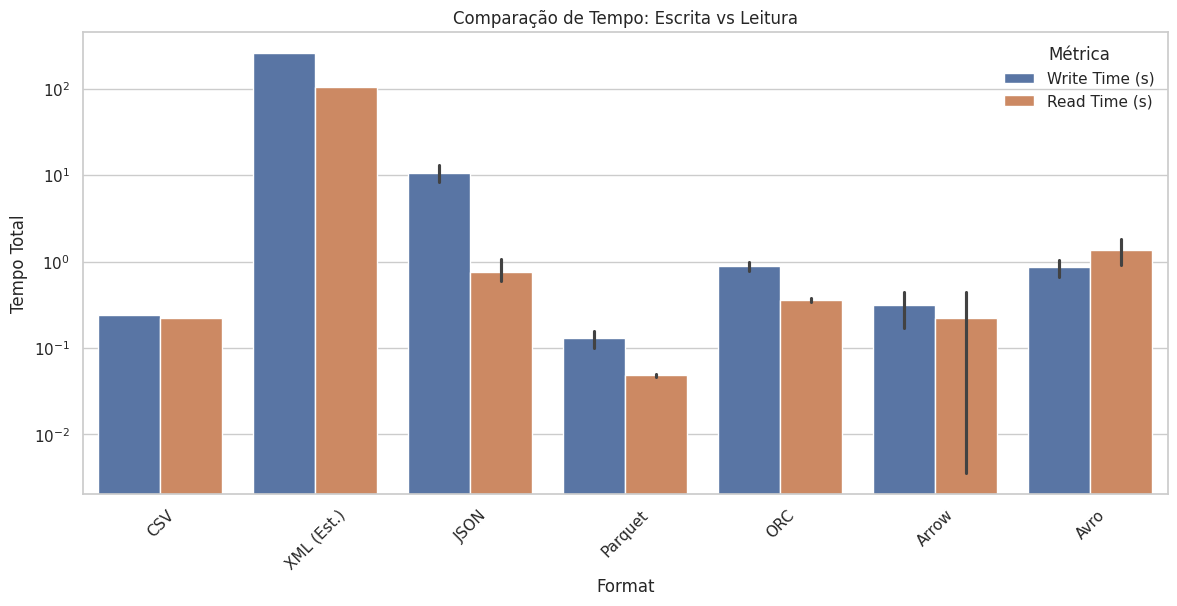

In [33]:
plt.figure(figsize=(14, 6))
metrics_df = df_final.melt(
    id_vars=["Format", "Compression"],
    value_vars=["Write Time (s)", "Read Time (s)"],
    var_name="Métrica",
    value_name="Tempo Total",
)
sns.barplot(data=metrics_df, x="Format", y="Tempo Total", hue="Métrica")
plt.title("Comparação de Tempo: Escrita vs Leitura")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

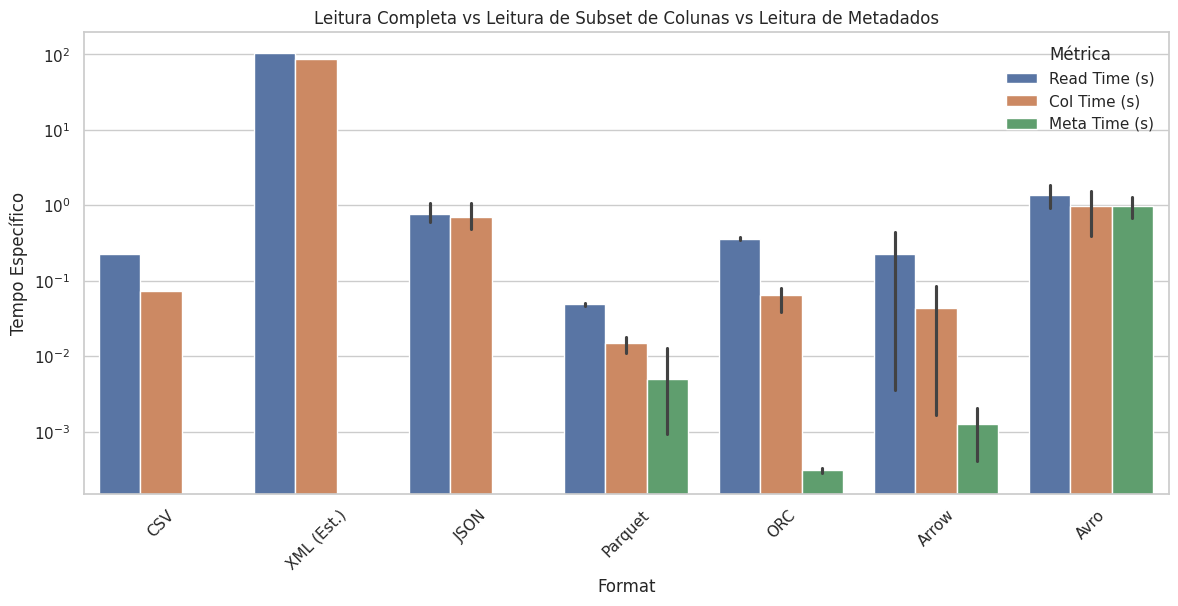

In [34]:
plt.figure(figsize=(14, 6))
read_metrics = df_final.melt(
    id_vars=["Format", "Compression"],
    value_vars=["Read Time (s)", "Col Time (s)", "Meta Time (s)"],
    var_name="Métrica",
    value_name="Tempo Específico",
)
sns.barplot(data=read_metrics, x="Format", y="Tempo Específico", hue="Métrica")
plt.title("Leitura Completa vs Leitura de Subset de Colunas vs Leitura de Metadados")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

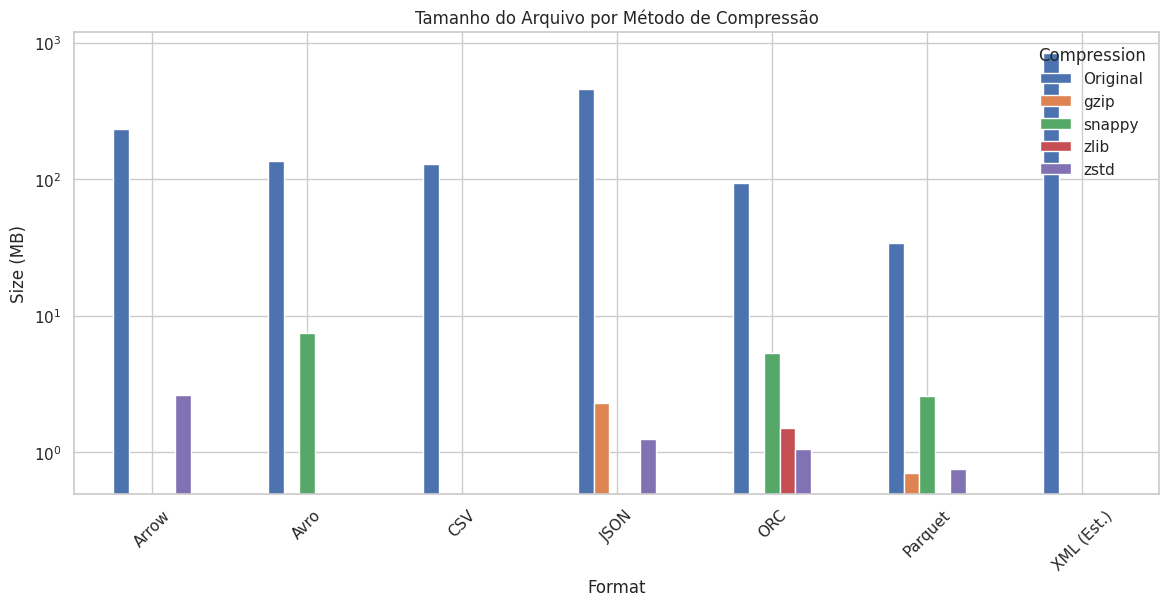

In [35]:
ax = df_final.pivot(index="Format", columns="Compression", values="Size (MB)").plot(
    kind="bar", figsize=(14, 6)
)
plt.title("Tamanho do Arquivo por Método de Compressão")
plt.ylabel("Size (MB)")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

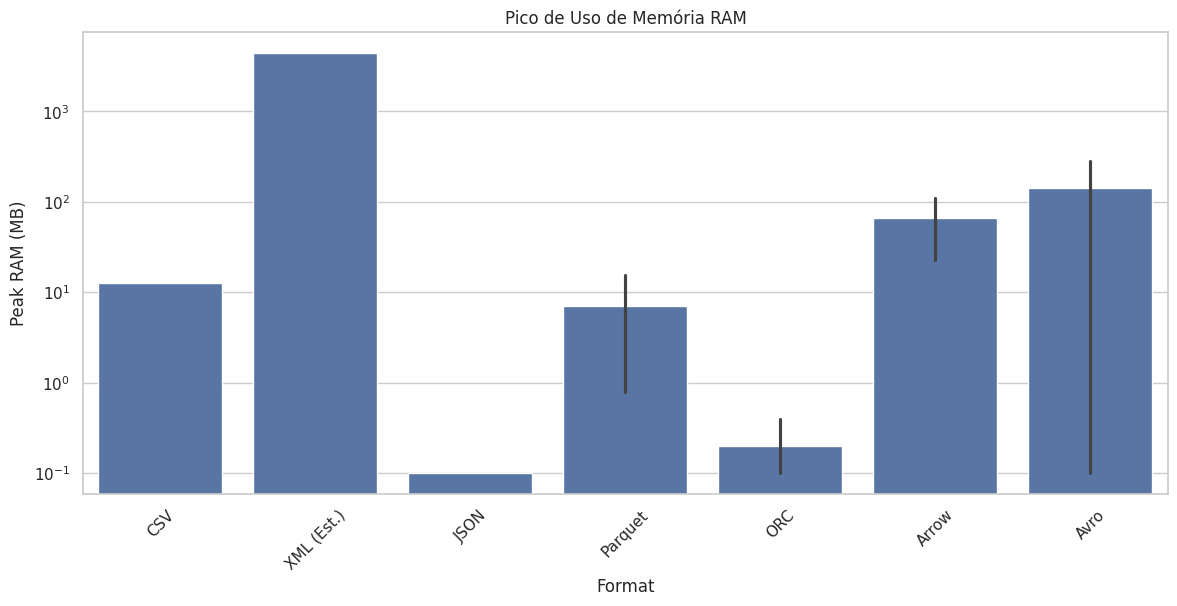

In [36]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_final, x="Format", y="Peak RAM (MB)")
plt.title("Pico de Uso de Memória RAM")
plt.yscale("log")
plt.xticks(rotation=45)
plt.show()

In [37]:
print(f"Tempo total de processamento: {time.time() - workflow_start:.2f}s")

Tempo total de processamento: 90.55s


### 6.5 Referências adicionais e nota de apoio

- **Parquet:** [Parquet File Format](https://parquet.apache.org/docs/file-format/) | [Parquet Concepts](https://parquet.apache.org/docs/concepts/)
- **ORC:** [ORC Spec v1](https://orc.apache.org/specification/ORCv1/) | [RCFile vs ORC](https://www.bigdatainrealworld.com/rcfile-vs-orc/)
- **Arrow:** [Arrow Columnar Format](https://arrow.apache.org/docs/format/Columnar.html)
- **Avro:** [Especificação Avro](https://avro.apache.org/docs/current/specification/)
- **Uso de IA:** Partes da consolidação teórica e da padronização de formatação deste notebook foram revisadas com apoio de IA generativa para checagem de clareza, consistência e fluidez do texto.


## 7. Apêndice Documental

Este apêndice reúne um resumo dos documentos que ajudam a entender o percurso do projeto, suas validações e os limites ainda presentes na versão atual.


### 7.1 Resumo da validação de consonância

A validação consolidada concluiu que o repositório está **substancialmente conforme** ao `PROJETO DE PESQUISA DOIS`. Os pontos centrais desse resultado são:

- adoção de uma leitura descritiva, comparativa e multicausal;
- cobertura das bases centrais (`populacao`, `PAM`, `PPM`, `Censo Agropecuario`, `INEP`);
- integração territorial por `codigo_municipio` de 7 dígitos;
- presença de `matriculas_ensino_medio_rural_2024`, `taxa_abandono_rural_2024` e `regime_territorial`;
- execução local da análise com validações internas consistentes.

As ressalvas restantes se concentram principalmente na documentação de alto nível e em limitações de cobertura, como a presença elevada de `dados_insuficientes` no snapshot final.
